# 0. Setup

In [81]:
import uproot, awkward as ak, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
 
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("device:", device)

device: mps


# 1. Configuration

In [82]:
# ── Data ──────────────────────────────────────────────────────────────────────
input_files = {
    "at_1_bt_0": "Delphes_Data/at_1_bt_0/tag_1_delphes_events.root",
    "at_0_bt_1": "Delphes_Data/at_0_bt_1/tag_1_delphes_events.root",
    "at_1_bt_1": "Delphes_Data/at_1_bt_1/tag_1_delphes_events.root",
}
TREE_NAME           = "Delphes"
MAX_JETS            = 12
RANDOM_SEED         = 42
REQUIRE_2_PHOTONS   = True
REQUIRE_2_RECO_JETS = True
USE_MASS_WINDOW     = True
MASS_WINDOW         = 15.0      # GeV around Higgs mass
DEBUG               = False
MAX_DEBUG_EVENTS    = 50000

# ── Target layout ─────────────────────────────────────────────────────────────
# H:  (log1p_pt, eta, sin(phi), cos(phi), log1p_E) — energy learned directly
# j1: (log1p_pt, eta, sin(phi), cos(phi), log1p_m) — mass learned directly
# j2: (log1p_pt, eta, sin(Δφ_jj), cos(Δφ_jj), log1p_m) — mass learned directly
# j2 phi slot encodes Δφ_jj = delta_phi(j1, j2) as (sin(Δφ_jj), cos(Δφ_jj))
# E for j1/j2 derived post-sampling: E = sqrt(pt²·cosh²(η) + m²)


TARGET_MODE    = "Hjj"
ORDERING       = "pt_ordered"
N_FEATURES     = 5              # log1p_pt, eta, sin(phi), cos(phi), log1p_E
TRUTH_OBJECTS  = ["H", "j1", "j2"]
BLOCK_SLICES   = {
    name: slice(i * N_FEATURES, (i + 1) * N_FEATURES)
    for i, name in enumerate(TRUTH_OBJECTS)
}
# y_dim = 15

# ── Reco input layout ─────────────────────────────────────────────────────────
N_RECO_FEATURES_PER_JET = 6    # log1p_pt, eta, sinphi, cosphi, mass, log1p_E  ← updated
N_RECO_HIGGS_FEATURES   = 6    # log1p_pt, eta, sinphi, cosphi, mass, log1p_E  ← updated
N_RECO_SCALAR_FEATURES  = 1    # log1p(njet)
# x_dim = 6 + 1 + 12*6 = 79                                                    ← updated

# ── Dataset slicing (re-run from Cell 6 without reloading) ────────────────────
N_EVENTS  = None    # None = use all available events
TEST_SIZE = 0.2

# ── Model ─────────────────────────────────────────────────────────────────────
COUPLING_TYPE     = "rqs"   # "affine" | "rqs"
N_BLOCKS          = 32
# affine only
AFFINE_CLAMP      = 2.0
# rqs only
SPLINE_BINS       = 16
SPLINE_TAIL       = 6.0
# conditioning subnet (preprocesses reco input before coupling blocks)
COND_SUBNET_WIDTH = 512
COND_SUBNET_DEPTH = 3       # number of hidden layers
# coupling subnet (inside each coupling block)
SUBNET_WIDTH      = 256

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 2048
EPOCHS     = 500
PATIENCE   = 100
LR         = 1e-4

# ── Seeds ─────────────────────────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# 2. Helper functions

In [83]:
# ── Angular helpers ───────────────────────────────────────────────────────────

def delta_phi(phi1, phi2):
    """Compute angular difference in [-pi, pi]."""
    return (phi1 - phi2 + np.pi) % (2 * np.pi) - np.pi


# ── Feature extraction from truth target ─────────────────────────────────────
# Truth layout:
# H:  [log1p_pt, eta, sin(phi), cos(phi), log1p_E]
# j1: [log1p_pt, eta, sin(phi), cos(phi), log1p_m]
# j2: [log1p_pt, eta, sin(Δφ_jj), cos(Δφ_jj), log1p_m]

def block(arr, name):
    return arr[..., BLOCK_SLICES[name]]

def pt_from_features(feat):
    return np.expm1(feat[..., 0])

def eta_from_features(feat):
    return feat[..., 1]

def phi_from_features(feat):
    return np.arctan2(feat[..., 2], feat[..., 3])

def E_from_features(feat):
    return np.expm1(feat[..., 4])

def mass_from_features(feat):
    """For j1/j2 only — 5th slot is log1p_m, not log1p_E."""
    return np.expm1(feat[..., 4])

def phi_j2_from_samples(samples):
    phi_j1  = phi_from_features(block(samples, "j1"))
    dphi_jj = phi_from_features(block(samples, "j2"))
    return delta_phi(phi_j1, dphi_jj)

def dphi_jj_from_samples(samples):
    return phi_from_features(block(samples, "j2"))

def deta_jj_from_samples(samples):
    return (
        eta_from_features(block(samples, "j1"))
        - eta_from_features(block(samples, "j2"))
    )


# ── Feature extraction from reco input ───────────────────────────────────────
# Reco layout per object: [log1p_pt, eta, sinphi, cosphi, mass, log1p_E]  ← updated

def pt_from_reco_features(feat):
    return np.expm1(feat[..., 0])

def eta_from_reco_features(feat):
    return feat[..., 1]

def phi_from_reco_features(feat):
    return np.arctan2(feat[..., 2], feat[..., 3])

def mass_from_reco_features(feat):
    return feat[..., 4]

def E_from_reco_features(feat):                  # ← new
    return np.expm1(feat[..., 5])

def jet_features_from_reco_X(X_row, jet_idx):
    start = N_RECO_HIGGS_FEATURES + N_RECO_SCALAR_FEATURES + jet_idx * N_RECO_FEATURES_PER_JET
    end   = start + N_RECO_FEATURES_PER_JET
    return X_row[start:end]

def higgs_features_from_reco_X(X_row):
    return X_row[0:N_RECO_HIGGS_FEATURES]


# ── ML feature construction ───────────────────────────────────────────────────

def to_ml_features_truth(pt, eta, phi, val):
    """
    Truth features: (log1p_pt, eta, sin(phi), cos(phi), log1p_val)
    val is log1p_E for Higgs, log1p_m for j1/j2.
    """
    return np.stack(
        [np.log1p(pt), eta, np.sin(phi), np.cos(phi), np.log1p(val)],
        axis=-1,
    )

def to_ml_features_reco(pt, eta, phi, mass, E):          # ← E added
    """
    Reco features: (log1p_pt, eta, sin(phi), cos(phi), mass, log1p_E)
    Now 6 features — energy added as 6th dimension.
    """
    return np.stack(
        [np.log1p(pt), eta, np.sin(phi), np.cos(phi), mass, np.log1p(E)],  # ← updated
        axis=-1,
    )


# ── Four-vector reconstruction ────────────────────────────────────────────────

def four_vector_from_E_pt_eta_phi(E, pt, eta, phi):
    """
    Build (E, px, py, pz) from learned E, pt, eta, phi.
    No mass assumption — E comes directly from the flow.
    """
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    return np.stack([E, px, py, pz], axis=-1)

def mass_from_four_vector(fv):
    """
    Recover invariant mass from four-vector.
    m² = E² - px² - py² - pz²
    Clamp to 0 to handle floating point noise.
    """
    E, px, py, pz = fv[..., 0], fv[..., 1], fv[..., 2], fv[..., 3]
    m2 = E**2 - px**2 - py**2 - pz**2
    return np.sqrt(np.maximum(m2, 0.0))

def reconstruct_four_vectors(samples):
    """
    Reconstruct four-vectors for H, j1, j2 from flow samples.
    H: E learned directly.
    j1/j2: mass learned directly, E derived as sqrt(pt²·cosh²(η) + m²).

    samples: shape (N, 15)
    returns: dict of four-vectors, each shape (N, 4)
    """
    H_feat  = block(samples, "H")
    j1_feat = block(samples, "j1")
    j2_feat = block(samples, "j2")
    phi_j2  = phi_j2_from_samples(samples)

    # j1 — derive E from pt, eta, mass
    pt_j1  = pt_from_features(j1_feat)
    eta_j1 = eta_from_features(j1_feat)
    m_j1   = mass_from_features(j1_feat)
    E_j1   = np.sqrt(pt_j1**2 * np.cosh(eta_j1)**2 + m_j1**2)

    # j2 — derive E from pt, eta, mass
    pt_j2  = pt_from_features(j2_feat)
    eta_j2 = eta_from_features(j2_feat)
    m_j2   = mass_from_features(j2_feat)
    E_j2   = np.sqrt(pt_j2**2 * np.cosh(eta_j2)**2 + m_j2**2)

    return {
        "H": four_vector_from_E_pt_eta_phi(
            E_from_features(H_feat),
            pt_from_features(H_feat),
            eta_from_features(H_feat),
            phi_from_features(H_feat),
        ),
        "j1": four_vector_from_E_pt_eta_phi(
            E_j1, pt_j1, eta_j1,
            phi_from_features(j1_feat),
        ),
        "j2": four_vector_from_E_pt_eta_phi(
            E_j2, pt_j2, eta_j2,
            phi_j2,
        ),
    }


# ── Reco Higgs reconstruction from diphotons ──────────────────────────────────

def photons_to_higgs(pt1, eta1, phi1, e1, pt2, eta2, phi2, e2):
    px1 = pt1 * np.cos(phi1);  py1 = pt1 * np.sin(phi1);  pz1 = pt1 * np.sinh(eta1)
    px2 = pt2 * np.cos(phi2);  py2 = pt2 * np.sin(phi2);  pz2 = pt2 * np.sinh(eta2)
    e  = e1 + e2;  px = px1 + px2;  py = py1 + py2;  pz = pz1 + pz2
    pt   = np.sqrt(px**2 + py**2)
    phi  = np.arctan2(py, px)
    p    = np.sqrt(px**2 + py**2 + pz**2)
    eta  = 0.5 * np.log((p + pz + 1e-12) / (p - pz + 1e-12))
    mass = np.sqrt(np.maximum(e**2 - px**2 - py**2 - pz**2, 0.0))
    return pt, eta, phi, mass, e                             # ← return e

# 3. Load one Delphes file and build paired reco/truth rows

In [84]:
branches = [
    "Particle.PID", "Particle.Status",
    "Particle.PT", "Particle.Eta", "Particle.Phi", "Particle.Mass",
    "Particle.E",
    "Jet.PT", "Jet.Eta", "Jet.Phi", "Jet.Mass",
    "Photon.PT", "Photon.Eta", "Photon.Phi", "Photon.E",
]


def build_dataset_from_file(path, sample_name, max_jets=MAX_JETS):
    with uproot.open(path) as f:
        arr = f[TREE_NAME].arrays(branches, library="ak")

    pid    = arr["Particle.PID"]
    status = arr["Particle.Status"]

    is_higgs       = (pid == 25) & (status == 22)
    is_hard_parton = (status == 23) & ((pid == 21) | (abs(pid) <= 5))

    h_pt  = arr["Particle.PT"][is_higgs]
    h_eta = arr["Particle.Eta"][is_higgs]
    h_phi = arr["Particle.Phi"][is_higgs]
    h_E   = arr["Particle.E"][is_higgs]

    p_pt  = arr["Particle.PT"][is_hard_parton]
    p_eta = arr["Particle.Eta"][is_hard_parton]
    p_phi = arr["Particle.Phi"][is_hard_parton]
    p_E   = arr["Particle.E"][is_hard_parton]
    p_m   = arr["Particle.Mass"][is_hard_parton] 

    n_higgs   = ak.num(h_pt)
    n_partons = ak.num(p_pt)
    n_jets    = ak.num(arr["Jet.PT"])
    n_photons = ak.num(arr["Photon.PT"])

    mask = (n_higgs == 1) & (n_partons == 2)
    if REQUIRE_2_PHOTONS:   mask = mask & (n_photons >= 2)
    if REQUIRE_2_RECO_JETS: mask = mask & (n_jets >= 2)

    pho_pt  = arr["Photon.PT"]
    pho_eta = arr["Photon.Eta"]
    pho_phi = arr["Photon.Phi"]
    pho_e   = arr["Photon.E"]

    # ── Reco Higgs from diphotons ─────────────────────────────────────────────
    hrec_pt, hrec_eta, hrec_phi, hrec_m, hrec_e = photons_to_higgs(   # ← capture hrec_e
        ak.to_numpy(pho_pt[mask][:, 0]),  ak.to_numpy(pho_eta[mask][:, 0]),
        ak.to_numpy(pho_phi[mask][:, 0]), ak.to_numpy(pho_e[mask][:, 0]),
        ak.to_numpy(pho_pt[mask][:, 1]),  ak.to_numpy(pho_eta[mask][:, 1]),
        ak.to_numpy(pho_phi[mask][:, 1]), ak.to_numpy(pho_e[mask][:, 1]),
    )

    mass_mask_np = np.ones(len(hrec_m), dtype=bool)
    if USE_MASS_WINDOW:
        mass_mask_np = np.abs(hrec_m - 125.0) < MASS_WINDOW

    arr_sel   = arr[mask]
    h_pt_sel  = h_pt[mask];  h_eta_sel = h_eta[mask];  h_phi_sel = h_phi[mask]
    h_E_sel   = h_E[mask]
    p_pt_sel  = p_pt[mask];  p_eta_sel = p_eta[mask]
    p_phi_sel = p_phi[mask]
    p_E_sel   = p_E[mask]
    p_m_sel   = p_m[mask] 

    # ── Truth target construction ─────────────────────────────────────────────
    truth_h = to_ml_features_truth(
        ak.to_numpy(h_pt_sel[:, 0])[mass_mask_np],
        ak.to_numpy(h_eta_sel[:, 0])[mass_mask_np],
        ak.to_numpy(h_phi_sel[:, 0])[mass_mask_np],
        ak.to_numpy(h_E_sel[:, 0])[mass_mask_np],
    )

    p_pt_np  = ak.to_numpy(p_pt_sel)[mass_mask_np]
    p_eta_np = ak.to_numpy(p_eta_sel)[mass_mask_np]
    p_phi_np = ak.to_numpy(p_phi_sel)[mass_mask_np]
    p_E_np   = ak.to_numpy(p_E_sel)[mass_mask_np]
    p_m_np   = ak.to_numpy(p_m_sel)[mass_mask_np]

    # order hard partons by pT: leading pT first
    swap = p_pt_np[:, 0] < p_pt_np[:, 1]
    for a in [p_pt_np, p_eta_np, p_phi_np, p_E_np, p_m_np]:
        tmp = a[swap, 0].copy()
        a[swap, 0] = a[swap, 1]
        a[swap, 1] = tmp

    truth_p1 = to_ml_features_truth(
        p_pt_np[:, 0], p_eta_np[:, 0], p_phi_np[:, 0], p_m_np[:, 0]
    )
    dphi_jj  = delta_phi(p_phi_np[:, 0], p_phi_np[:, 1])
    truth_p2 = to_ml_features_truth(
        p_pt_np[:, 1], p_eta_np[:, 1], dphi_jj, p_m_np[:, 1]
    )

    y_truth = np.concatenate([truth_h, truth_p1, truth_p2], axis=1)  # (N, 15)

    # ── Reco feature construction ─────────────────────────────────────────────
    # Reco Higgs energy from diphoton sum
    hrec_feat = to_ml_features_reco(
        hrec_pt[mass_mask_np], hrec_eta[mass_mask_np],
        hrec_phi[mass_mask_np], hrec_m[mass_mask_np],
        hrec_e[mass_mask_np],                                          # ← added
    )

    jet_pt  = arr_sel["Jet.PT"][mass_mask_np]
    jet_eta = arr_sel["Jet.Eta"][mass_mask_np]
    jet_phi = arr_sel["Jet.Phi"][mass_mask_np]
    jet_m   = arr_sel["Jet.Mass"][mass_mask_np]

    n_events  = len(y_truth)
    reco_jets = np.zeros((n_events, max_jets, N_RECO_FEATURES_PER_JET), dtype=np.float32)

    for j in range(max_jets):
        has_j = ak.num(jet_pt) > j
        idx   = np.where(ak.to_numpy(has_j))[0]
        if len(idx) == 0:
            continue

        jpt  = ak.to_numpy(jet_pt[has_j][:, j])
        jeta = ak.to_numpy(jet_eta[has_j][:, j])
        jphi = ak.to_numpy(jet_phi[has_j][:, j])
        jm   = ak.to_numpy(jet_m[has_j][:, j])

        # compute jet energy from pt, eta, mass — no Jet.E branch available
        jE   = np.sqrt(jpt**2 * np.cosh(jeta)**2 + jm**2)            # ← computed

        reco_jets[idx, j, :] = to_ml_features_reco(jpt, jeta, jphi, jm, jE)  # ← added jE

    njets_np   = ak.to_numpy(ak.num(jet_pt)).astype(np.float32)
    njets_feat = np.log1p(njets_np).reshape(-1, 1)

    x_reco = np.concatenate([
        hrec_feat,
        njets_feat,
        reco_jets.reshape(n_events, max_jets * N_RECO_FEATURES_PER_JET),
    ], axis=1)  # (N, 79)                                              # ← updated comment

    meta = pd.DataFrame({
        "sample":          sample_name,
        "n_reco_jets":     njets_np,
        "reco_higgs_mass": hrec_m[mass_mask_np],
    })

    return x_reco.astype(np.float32), y_truth.astype(np.float32), meta

# 4. Build combined dataset from all at/bt configurations

In [85]:
# Re-running this cell is the only time you pay the I/O cost.
# After this, X_full / y_full / meta_full live in RAM.
 
X_list, y_list, meta_list = [], [], []
 
for name, path in input_files.items():
    X_i, y_i, meta_i = build_dataset_from_file(path, name)
    print(f"{name} — X: {X_i.shape}, y: {y_i.shape}")
    X_list.append(X_i)
    y_list.append(y_i)
    meta_list.append(meta_i)
 
X_full    = np.concatenate(X_list, axis=0)
y_full    = np.concatenate(y_list, axis=0)
meta_full = pd.concat(meta_list, axis=0).reset_index(drop=True)
 
assert y_full.shape[1] == len(TRUTH_OBJECTS) * N_FEATURES, \
    f"y_dim mismatch: got {y_full.shape[1]}, expected {len(TRUTH_OBJECTS) * N_FEATURES}"
 
print(f"\nFull dataset — X: {X_full.shape}, y: {y_full.shape}")
print(f"Total events: {len(X_full):,}")
print("\nSample counts:")
print(meta_full["sample"].value_counts())

at_1_bt_0 — X: (88020, 79), y: (88020, 15)
at_0_bt_1 — X: (87895, 79), y: (87895, 15)
at_1_bt_1 — X: (88178, 79), y: (88178, 15)

Full dataset — X: (264093, 79), y: (264093, 15)
Total events: 264,093

Sample counts:
sample
at_1_bt_1    88178
at_1_bt_0    88020
at_0_bt_1    87895
Name: count, dtype: int64


# 5. Shuffle reco/truth together

In [86]:
# Re-running this changes the shuffle but NOT the data loaded.
# Only re-run if you want a fresh shuffle.
 
perm   = np.random.permutation(len(X_full))
X_full = X_full[perm]
y_full = y_full[perm]
meta_full = meta_full.iloc[perm].reset_index(drop=True)
 
if DEBUG:
    print(f"DEBUG MODE: keeping first {MAX_DEBUG_EVENTS} events")
    X_full    = X_full[:MAX_DEBUG_EVENTS]
    y_full    = y_full[:MAX_DEBUG_EVENTS]
    meta_full = meta_full.iloc[:MAX_DEBUG_EVENTS].reset_index(drop=True)
 
print(f"Shuffled dataset — X: {X_full.shape}, y: {y_full.shape}")

Shuffled dataset — X: (264093, 79), y: (264093, 15)


# 6. Train/validation split and scaling

In [87]:
# Re-run this freely to change N_EVENTS, TEST_SIZE, or scaling.
# Does NOT require reloading from disk.
 
# ── Slice ─────────────────────────────────────────────────────────────────────
N = len(X_full) if N_EVENTS is None else min(N_EVENTS, len(X_full))
X = X_full[:N]
y = y_full[:N]
meta = meta_full.iloc[:N].reset_index(drop=True)
 
print(f"Using {N:,} events ({N/len(X_full)*100:.1f}% of full dataset)")
 
# ── Train / val split ─────────────────────────────────────────────────────────
X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    X, y, meta,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
)
 
# ── Reco scaling ──────────────────────────────────────────────────────────────
# Fit on Higgs + njet + first 2 jet slots only.
# Reuse jet-1 statistics for all jet slots to avoid ±400 values in
# zero-padded high-index slots.
 
N_HIGGS_AND_NJET = N_RECO_HIGGS_FEATURES + N_RECO_SCALAR_FEATURES   # 6
fit_cols = list(range(N_HIGGS_AND_NJET + 2 * N_RECO_FEATURES_PER_JET))
 
x_scaler = StandardScaler()
x_scaler.fit(X_train[:, fit_cols])
 
x_mean  = np.zeros(X_train.shape[1], dtype=np.float32)
x_scale = np.ones(X_train.shape[1],  dtype=np.float32)
 
x_mean[:N_HIGGS_AND_NJET]  = x_scaler.mean_[:N_HIGGS_AND_NJET]
x_scale[:N_HIGGS_AND_NJET] = x_scaler.scale_[:N_HIGGS_AND_NJET]
 
jet1_mean  = x_scaler.mean_[N_HIGGS_AND_NJET : N_HIGGS_AND_NJET + N_RECO_FEATURES_PER_JET]
jet1_scale = x_scaler.scale_[N_HIGGS_AND_NJET : N_HIGGS_AND_NJET + N_RECO_FEATURES_PER_JET]
 
for j in range(MAX_JETS):
    s = N_HIGGS_AND_NJET + j * N_RECO_FEATURES_PER_JET
    x_mean[s:s + N_RECO_FEATURES_PER_JET]  = jet1_mean
    x_scale[s:s + N_RECO_FEATURES_PER_JET] = jet1_scale
 
X_train_s = ((X_train - x_mean) / x_scale).astype(np.float32)
X_val_s   = ((X_val   - x_mean) / x_scale).astype(np.float32)
 
print(f"X_train_s min/max: {X_train_s.min():.2f} / {X_train_s.max():.2f}")
 
# ── Truth scaling ─────────────────────────────────────────────────────────────
y_scaler  = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train).astype(np.float32)
y_val_s   = y_scaler.transform(y_val).astype(np.float32)
 
print(f"y_train_s min/max: {y_train_s.min():.2f} / {y_train_s.max():.2f}")
 
# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = TensorDataset(torch.tensor(y_train_s), torch.tensor(X_train_s))
val_ds   = TensorDataset(torch.tensor(y_val_s),   torch.tensor(X_val_s))
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
 
x_dim = X_train_s.shape[1]   # 66
y_dim = y_train_s.shape[1]   # 12
 
print(f"\nReco dim  (x_dim):  {x_dim}")
print(f"Truth dim (y_dim):  {y_dim}")
print(f"Train events: {len(X_train):,}  |  Val events: {len(X_val):,}")
 
# Torch versions of scaler params (kept for physics penalty / future use)
y_mean_t  = torch.tensor(y_scaler.mean_,  dtype=torch.float32, device=device)
y_scale_t = torch.tensor(y_scaler.scale_, dtype=torch.float32, device=device)

Using 264,093 events (100.0% of full dataset)
X_train_s min/max: -11.81 / 22.96
y_train_s min/max: -5.55 / 7.51

Reco dim  (x_dim):  79
Truth dim (y_dim):  15
Train events: 211,274  |  Val events: 52,819


# 7. Build cINN / conditional flow with FrEIA

In [88]:
# ── Conditioning subnet ───────────────────────────────────────────────────────

class ConditioningSubnet(nn.Module):
    """
    MLP that preprocesses the reco conditioning vector.
    Input:  (batch, context_dim)   e.g. 66
    Output: (batch, COND_SUBNET_WIDTH)
    """
    def __init__(self, context_dim, width=COND_SUBNET_WIDTH, depth=COND_SUBNET_DEPTH):
        super().__init__() 
        layers = []
        in_dim = context_dim
        for _ in range(depth):
            layers += [nn.Linear(in_dim, width), nn.GELU()]
            in_dim  = width
        self.net = nn.Sequential(*layers)
        self.out_dim = width

    def forward(self, x):
        return self.net(x)


# ── Coupling subnet ───────────────────────────────────────────────────────────

def make_subnet(in_dim, out_dim, width=SUBNET_WIDTH):
    return nn.Sequential(
        nn.Linear(in_dim, width),
        nn.GELU(),
        nn.Dropout(p=0.1),
        nn.Linear(width, width),
        nn.GELU(),
        nn.Dropout(p=0.1),
        nn.Linear(width, out_dim),
    )


# ── Affine coupling block ─────────────────────────────────────────────────────

class AffineCouplingBlock(nn.Module):
    def __init__(self, x_dim, context_dim, clamp=AFFINE_CLAMP, width=SUBNET_WIDTH):
        super().__init__()
        self.x1_dim = x_dim // 2
        self.x2_dim = x_dim - self.x1_dim
        self.clamp  = clamp
        self.subnet = make_subnet(self.x1_dim + context_dim, self.x2_dim * 2, width=width)

    def _st(self, x1, context):
        h    = self.subnet(torch.cat([x1, context], dim=-1))
        s, t = h.chunk(2, dim=-1)
        s    = self.clamp * torch.tanh(s / self.clamp)
        return s, t

    def forward(self, x, context):
        x1, x2  = x[:, :self.x1_dim], x[:, self.x1_dim:]
        s, t    = self._st(x1, context)
        z2      = x2 * torch.exp(s) + t
        log_det = s.sum(dim=-1)
        return torch.cat([x1, z2], dim=-1), log_det

    def inverse(self, z, context):
        z1, z2 = z[:, :self.x1_dim], z[:, self.x1_dim:]
        s, t   = self._st(z1, context)
        x2     = (z2 - t) * torch.exp(-s)
        return torch.cat([z1, x2], dim=-1)


# ── Rational Quadratic Spline ─────────────────────────────────────────────────
# Durkan et al. 2019 — Neural Spline Flows, NeurIPS

def _rqs_forward_batched(x, widths, heights, derivatives, tail):
    """
    Vectorised RQS forward pass.
    x:           (batch, D)
    widths:      (batch, D, K)
    heights:     (batch, D, K)
    derivatives: (batch, D, K+1)
    returns:     z (batch, D), log_det (batch, D)
    """
    cum_w = F.pad(torch.cumsum(widths,  dim=-1), (1, 0), value=0.0) - tail
    cum_h = F.pad(torch.cumsum(heights, dim=-1), (1, 0), value=0.0) - tail

    bin_idx = (x.unsqueeze(-1) >= cum_w[..., :-1]).sum(dim=-1) - 1
    bin_idx = bin_idx.clamp(0, widths.shape[-1] - 1)

    idx  = bin_idx.unsqueeze(-1)
    w_k  = widths.gather(-1, idx).squeeze(-1)
    h_k  = heights.gather(-1, idx).squeeze(-1)
    d_k  = derivatives[..., :-1].gather(-1, idx).squeeze(-1)
    d_k1 = derivatives[..., 1:].gather(-1, idx).squeeze(-1)
    x_k  = cum_w[..., :-1].gather(-1, idx).squeeze(-1)
    y_k  = cum_h[..., :-1].gather(-1, idx).squeeze(-1)

    s_k = h_k / w_k
    xi  = ((x - x_k) / w_k).clamp(0.0, 1.0)

    num    = h_k * (s_k * xi**2 + d_k * xi * (1 - xi))
    den    = s_k + ((d_k + d_k1 - 2 * s_k) * xi * (1 - xi))
    z      = y_k + num / den

    dnum   = 2 * s_k * xi * (1 - xi) + d_k * (1 - xi)**2 + d_k1 * xi**2
    log_dz = torch.log(s_k**2 * dnum) - 2 * torch.log(den.abs() + 1e-8)

    return z, log_dz


def _rqs_inverse_batched(z, widths, heights, derivatives, tail):
    """
    Vectorised RQS inverse pass.
    z:           (batch, D)
    widths:      (batch, D, K)
    heights:     (batch, D, K)
    derivatives: (batch, D, K+1)
    returns:     x (batch, D)
    """
    cum_w = F.pad(torch.cumsum(widths,  dim=-1), (1, 0), value=0.0) - tail
    cum_h = F.pad(torch.cumsum(heights, dim=-1), (1, 0), value=0.0) - tail

    bin_idx = (z.unsqueeze(-1) >= cum_h[..., :-1]).sum(dim=-1) - 1
    bin_idx = bin_idx.clamp(0, widths.shape[-1] - 1)

    idx  = bin_idx.unsqueeze(-1)
    w_k  = widths.gather(-1, idx).squeeze(-1)
    h_k  = heights.gather(-1, idx).squeeze(-1)
    d_k  = derivatives[..., :-1].gather(-1, idx).squeeze(-1)
    d_k1 = derivatives[..., 1:].gather(-1, idx).squeeze(-1)
    x_k  = cum_w[..., :-1].gather(-1, idx).squeeze(-1)
    y_k  = cum_h[..., :-1].gather(-1, idx).squeeze(-1)

    s_k  = h_k / w_k
    zeta = z - y_k

    a    =  h_k * (s_k - d_k)  + zeta * (d_k + d_k1 - 2 * s_k)
    b    =  h_k * d_k           - zeta * (d_k + d_k1 - 2 * s_k)
    c    = -s_k * zeta

    disc = (b**2 - 4 * a * c).clamp(min=0.0)
    xi   = (2 * c / (-b - torch.sqrt(disc))).clamp(0.0, 1.0)

    return xi * w_k + x_k


# ── RQS Coupling Block ────────────────────────────────────────────────────────

class RQSCouplingBlock(nn.Module):
    def __init__(self, x_dim, context_dim, K=SPLINE_BINS, tail=SPLINE_TAIL, width=SUBNET_WIDTH):
        super().__init__()
        self.x1_dim           = x_dim // 2
        self.x2_dim           = x_dim - self.x1_dim
        self.K                = K
        self.tail             = tail
        self.n_params_per_dim = 3 * K + 1
        self.subnet = make_subnet(
            self.x1_dim + context_dim,
            self.x2_dim * self.n_params_per_dim,
            width=width,
        )

    def _params(self, x1, context):
        raw = self.subnet(torch.cat([x1, context], dim=-1))
        raw = raw.view(*raw.shape[:-1], self.x2_dim, self.n_params_per_dim)
        W   = raw[..., :self.K]
        H   = raw[..., self.K : 2 * self.K]
        D   = raw[..., 2 * self.K:]
        return (
            F.softmax(W, dim=-1) * 2 * self.tail,
            F.softmax(H, dim=-1) * 2 * self.tail,
            F.softplus(D),
        )

    def forward(self, x, context):
        x1, x2 = x[:, :self.x1_dim], x[:, self.x1_dim:]
        widths, heights, derivatives = self._params(x1, context)

        inside        = ((x2 >= -self.tail) & (x2 <= self.tail)).float()
        z2_in, ld_in  = _rqs_forward_batched(x2, widths, heights, derivatives, self.tail)
        z2      = inside * z2_in + (1.0 - inside) * x2
        log_det = (inside * ld_in).sum(dim=-1)

        return torch.cat([x1, z2], dim=-1), log_det

    def inverse(self, z, context):
        z1, z2 = z[:, :self.x1_dim], z[:, self.x1_dim:]
        widths, heights, derivatives = self._params(z1, context)

        inside = ((z2 >= -self.tail) & (z2 <= self.tail)).float()
        x2_in  = _rqs_inverse_batched(z2, widths, heights, derivatives, self.tail)
        x2     = inside * x2_in + (1.0 - inside) * z2

        return torch.cat([z1, x2], dim=-1)


# ── Fixed random permutation ──────────────────────────────────────────────────

class Permutation(nn.Module):
    def __init__(self, dim, seed):
        super().__init__()
        rng  = np.random.RandomState(seed)
        perm = rng.permutation(dim).astype(np.int64)
        inv  = np.argsort(perm).astype(np.int64)
        self.register_buffer("perm", torch.tensor(perm))
        self.register_buffer("inv",  torch.tensor(inv))

    def forward(self, x):
        return x[:, self.perm]

    def inverse(self, x):
        return x[:, self.inv]


# ── cINN ──────────────────────────────────────────────────────────────────────

COUPLING_REGISTRY = {
    "affine": AffineCouplingBlock,
    "rqs":    RQSCouplingBlock,
}

class cINN(nn.Module):
    def __init__(
        self,
        target_dim,
        context_dim,
        n_blocks     = N_BLOCKS,
        coupling     = COUPLING_TYPE,
        cond_width   = COND_SUBNET_WIDTH,
        cond_depth   = COND_SUBNET_DEPTH,
        subnet_width = SUBNET_WIDTH,
    ):
        super().__init__()

        if coupling not in COUPLING_REGISTRY:
            raise ValueError(
                f"Unknown coupling type '{coupling}'. "
                f"Available: {list(COUPLING_REGISTRY.keys())}"
            )

        self.cond_net = ConditioningSubnet(context_dim, width=cond_width, depth=cond_depth)
        c_dim         = self.cond_net.out_dim

        CouplingClass = COUPLING_REGISTRY[coupling]
        self.blocks   = nn.ModuleList()
        self.perms    = nn.ModuleList()

        for k in range(n_blocks):
            self.blocks.append(CouplingClass(target_dim, c_dim, width=subnet_width))
            self.perms.append(Permutation(target_dim, seed=k))

    def forward(self, x, context):
        c       = self.cond_net(context)
        log_det = torch.zeros(x.shape[0], device=x.device)

        for block, perm in zip(self.blocks, self.perms):
            x, ld = block(x, c)
            log_det += ld
            x = perm(x)

        return x, log_det

    def inverse(self, z, context):
        c = self.cond_net(context)

        for block, perm in zip(reversed(self.blocks), reversed(self.perms)):
            z = perm.inverse(z)
            z = block.inverse(z, c)

        return z


# ── Instantiate ───────────────────────────────────────────────────────────────
model = cINN(
    target_dim   = y_dim,
    context_dim  = x_dim,
    n_blocks     = N_BLOCKS,
    coupling     = COUPLING_TYPE,
    cond_width   = COND_SUBNET_WIDTH,
    cond_depth   = COND_SUBNET_DEPTH,
    subnet_width = SUBNET_WIDTH,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(f"Coupling type:        {COUPLING_TYPE}")
print(f"N blocks:             {N_BLOCKS}")
print(f"Target dim (y_dim):   {y_dim}")
print(f"Context dim (x_dim):  {x_dim}")
print(f"Cond subnet:          {COND_SUBNET_DEPTH}x{COND_SUBNET_WIDTH}")
print(f"Coupling subnet:      2x{SUBNET_WIDTH}")

Trainable parameters: 10,155,264
Coupling type:        rqs
N blocks:             32
Target dim (y_dim):   15
Context dim (x_dim):  79
Cond subnet:          3x512
Coupling subnet:      2x256


# 8. Negative log-likelihood + physics penalty

In [89]:
def cinn_nll(model, x_truth, x_reco):
    """
    Gaussian NLL for a normalising flow:
        L = 0.5 * ||z||² - log|det J|
    """
    z, log_det = model(x_truth, x_reco)
    return torch.mean(0.5 * torch.sum(z**2, dim=1) - log_det)
 

# 9. Training loop with checkpointing + scheduler

In [90]:
# =============================================================================
# CELL 9 — Training loop
# =============================================================================

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = "min",
    patience = 20,
    factor   = 0.5,
)

train_losses     = []
val_losses       = []
best_val         = float("inf")
patience_counter = 0

run_timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
best_ckpt_path = (
    f"best_cinn_{run_timestamp}_"
    f"{TARGET_MODE}_{ORDERING}_"
    f"maxjets{MAX_JETS}_blocks{N_BLOCKS}_"
    f"lr{LR}_{COUPLING_TYPE}.pt"
)

MODEL_CONFIG = dict(
    target_dim   = y_dim,
    context_dim  = x_dim,
    n_blocks     = N_BLOCKS,
    coupling     = COUPLING_TYPE,
    cond_width   = COND_SUBNET_WIDTH,
    cond_depth   = COND_SUBNET_DEPTH,
    subnet_width = SUBNET_WIDTH,
    spline_bins  = SPLINE_BINS,
    spline_tail  = SPLINE_TAIL,
    affine_clamp = AFFINE_CLAMP,
    target_mode  = TARGET_MODE,
    ordering     = ORDERING,
    max_jets     = MAX_JETS,
    n_features   = N_FEATURES,
)

for epoch in range(EPOCHS):

    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for yb, xb in train_loader:
        yb = yb.to(device)
        xb = xb.to(device)

        optimizer.zero_grad()
        loss = cinn_nll(model, yb, xb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * len(yb)

    train_loss = running_loss / len(train_loader.dataset)

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    running_val = 0.0

    with torch.no_grad():
        for yb, xb in val_loader:
            yb = yb.to(device)
            xb = xb.to(device)
            running_val += cinn_nll(model, yb, xb).item() * len(yb)

    val_loss = running_val / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # ── Scheduler step ────────────────────────────────────────────────────────
    scheduler.step(val_loss)

    # ── Checkpoint + early stopping ───────────────────────────────────────────
    if val_loss < best_val:
        best_val         = val_loss
        patience_counter = 0
        torch.save({
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch":                epoch,
            "val_loss":             val_loss,
            "model_config":         MODEL_CONFIG,
        }, best_ckpt_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"epoch {epoch+1:03d} | "
        f"train {train_loss:.4f} | "
        f"val {val_loss:.4f} | "
        f"lr {current_lr:.2e} | "
        f"best {best_val:.4f}"
    )

print(f"\nBest checkpoint: {best_ckpt_path}")

epoch 001 | train 1.2864 | val -6.0767 | lr 1.00e-04 | best -6.0767
epoch 002 | train -7.4565 | val -11.8705 | lr 1.00e-04 | best -11.8705
epoch 003 | train -11.8651 | val -14.4904 | lr 1.00e-04 | best -14.4904
epoch 004 | train -13.9115 | val -16.6893 | lr 1.00e-04 | best -16.6893
epoch 005 | train -15.3124 | val -18.1080 | lr 1.00e-04 | best -18.1080
epoch 006 | train -16.5047 | val -18.8118 | lr 1.00e-04 | best -18.8118
epoch 007 | train -17.5753 | val -20.0294 | lr 1.00e-04 | best -20.0294
epoch 008 | train -18.1517 | val -19.8496 | lr 1.00e-04 | best -20.0294
epoch 009 | train -18.7406 | val -19.9179 | lr 1.00e-04 | best -20.0294
epoch 010 | train -18.8552 | val -21.6744 | lr 1.00e-04 | best -21.6744
epoch 011 | train -19.4228 | val -20.6387 | lr 1.00e-04 | best -21.6744
epoch 012 | train -20.0395 | val -23.0864 | lr 1.00e-04 | best -23.0864
epoch 013 | train -19.9241 | val -21.0867 | lr 1.00e-04 | best -23.0864
epoch 014 | train -20.8927 | val -21.5724 | lr 1.00e-04 | best -23.08

# 10. Training curves

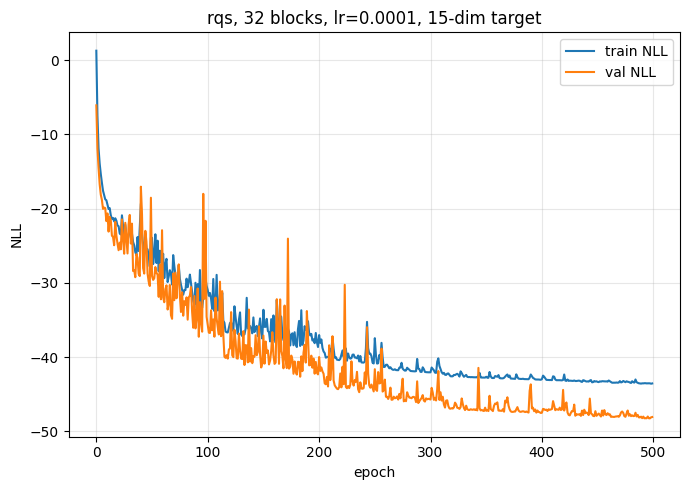

In [91]:
# ── Cell 10: Training curves ──────────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="train NLL")
plt.plot(val_losses,   label="val NLL")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.title(
    f"{COUPLING_TYPE}, {N_BLOCKS} blocks, "
    f"lr={LR}, {y_dim}-dim target"   # ← use y_dim instead of hardcoded 9
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [99]:
# ── Cell 11: Single-event posterior sampling ──────────────────

def sample_truth_given_reco(model, x_reco_scaled, n_samples=1000):
    """
    Generate posterior samples for a single reco event.
 
    x_reco_scaled : (context_dim,)
    returns       : (n_samples, y_dim) in unscaled truth space
    """
    model.eval()
    context = torch.tensor(x_reco_scaled[None, :], dtype=torch.float32, device=device)
    context = context.repeat(n_samples, 1)
    z       = torch.randn(n_samples, y_dim, device=device)
 
    with torch.no_grad():
        x_samples = model.inverse(z, context)
 
    return x_samples.cpu().numpy()


# ── Load best checkpoint before sampling ─────────────────────
checkpoint = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded epoch {checkpoint['epoch']+1}, val loss {checkpoint['val_loss']:.4f}")

# ── Sample for one validation event ──────────────────────────
idx            = 5
samples_scaled = sample_truth_given_reco(model, X_val_s[idx], n_samples=2000)
samples        = y_scaler.inverse_transform(samples_scaled)
truth          = y_val[idx]

print(f"samples shape: {samples.shape}")
print(f"truth shape:   {truth.shape}")
print(f"\nEvent info:")
print(f"  sample/config: {meta_val.iloc[idx]['sample']}")
print(f"  n reco jets:   {meta_val.iloc[idx]['n_reco_jets']}")
print(f"  reco H mass:   {meta_val.iloc[idx]['reco_higgs_mass']:.2f} GeV")

Loaded epoch 498, val loss -48.2493
samples shape: (2000, 15)
truth shape:   (15,)

Event info:
  sample/config: at_0_bt_1
  n reco jets:   5.0
  reco H mass:   126.47 GeV


# 12. Single-event posterior diagnostic: 
## hard truth vs detector vs flow posterior

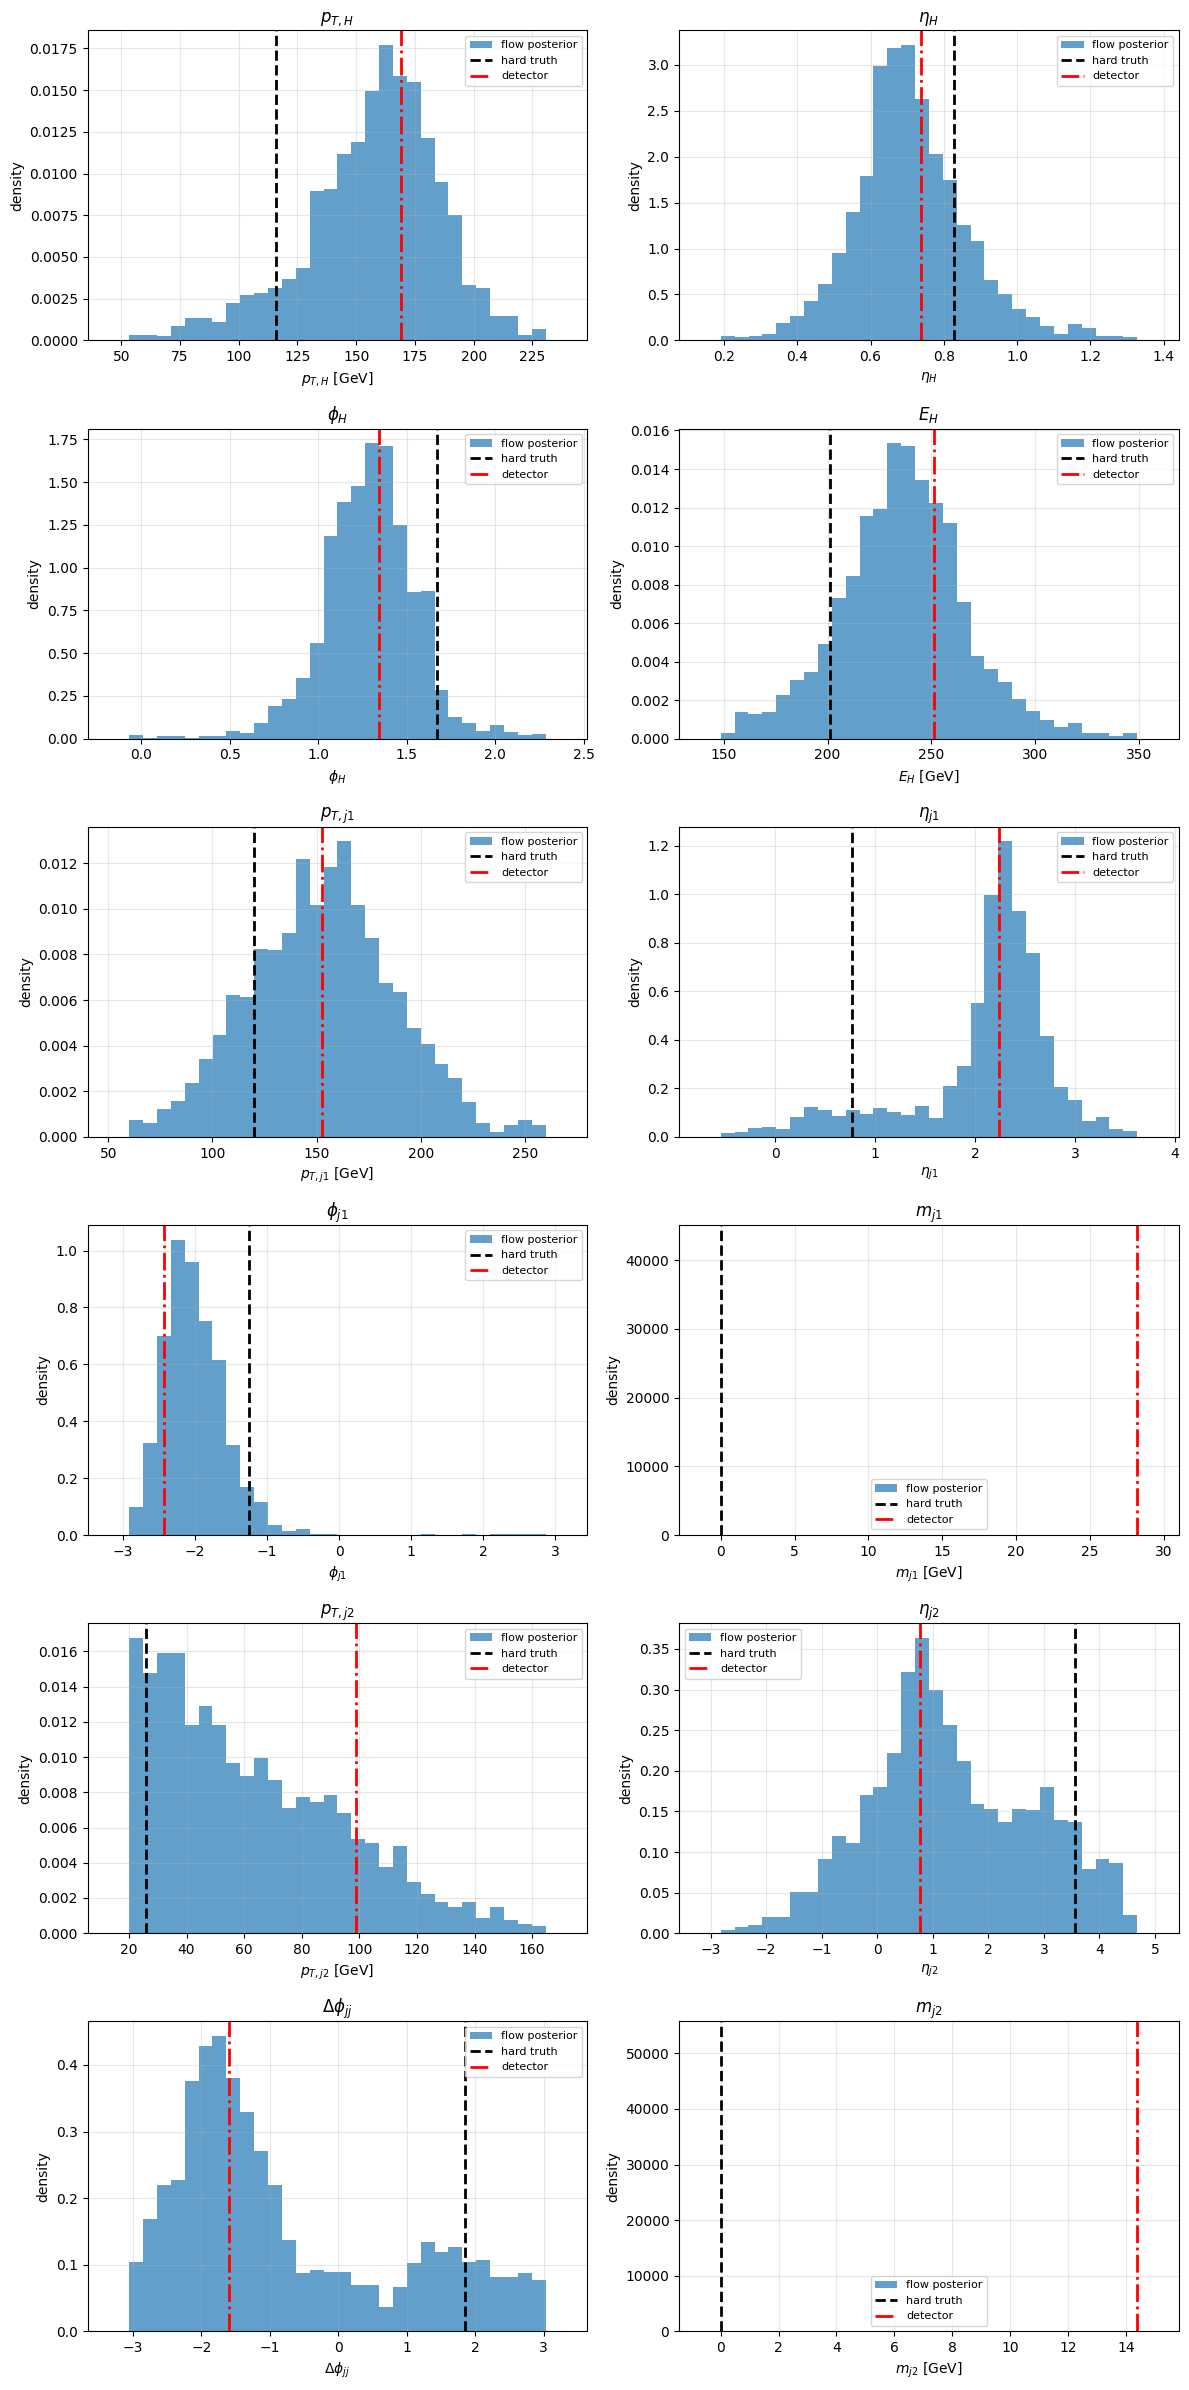

In [100]:
# ── Cell 12: Single-event posterior plots ────────────────────
# Layout: [H(5), j1(5), j2(5)] where j2 phi slot = Δφ_jj
s_H  = samples[:, BLOCK_SLICES["H"]]
s_p1 = samples[:, BLOCK_SLICES["j1"]]
s_p2 = samples[:, BLOCK_SLICES["j2"]]

t_H  = truth[BLOCK_SLICES["H"]]
t_p1 = truth[BLOCK_SLICES["j1"]]
t_p2 = truth[BLOCK_SLICES["j2"]]

rH  = higgs_features_from_reco_X(X_val[idx])
rj1 = jet_features_from_reco_X(X_val[idx], 0)
rj2 = jet_features_from_reco_X(X_val[idx], 1)

# ── Build variables dict ──────────────────────────────────────
variables = {}

# Higgs
variables[r"$p_{T,H}$"] = {
    "samples": pt_from_features(s_H),
    "truth":   pt_from_features(t_H),
    "reco":    pt_from_reco_features(rH),
    "xlabel":  r"$p_{T,H}$ [GeV]",
}
variables[r"$\eta_H$"] = {
    "samples": eta_from_features(s_H),
    "truth":   eta_from_features(t_H),
    "reco":    eta_from_reco_features(rH),
    "xlabel":  r"$\eta_H$",
}
variables[r"$\phi_H$"] = {
    "samples": phi_from_features(s_H),
    "truth":   phi_from_features(t_H),
    "reco":    phi_from_reco_features(rH),
    "xlabel":  r"$\phi_H$",
}
variables[r"$E_H$"] = {                          # ← new
    "samples": E_from_features(s_H),
    "truth":   E_from_features(t_H),
    "reco":    E_from_reco_features(rH),                            
    "xlabel":  r"$E_H$ [GeV]",
}

# j1
variables[r"$p_{T,j1}$"] = {
    "samples": pt_from_features(s_p1),
    "truth":   pt_from_features(t_p1),
    "reco":    pt_from_reco_features(rj1),
    "xlabel":  r"$p_{T,j1}$ [GeV]",
}
variables[r"$\eta_{j1}$"] = {
    "samples": eta_from_features(s_p1),
    "truth":   eta_from_features(t_p1),
    "reco":    eta_from_reco_features(rj1),
    "xlabel":  r"$\eta_{j1}$",
}
variables[r"$\phi_{j1}$"] = {
    "samples": phi_from_features(s_p1),
    "truth":   phi_from_features(t_p1),
    "reco":    phi_from_reco_features(rj1),
    "xlabel":  r"$\phi_{j1}$",
}
variables[r"$m_{j1}$"] = {
    "samples": mass_from_features(s_p1),
    "truth":   mass_from_features(t_p1),
    "reco":    mass_from_reco_features(rj1),
    "xlabel":  r"$m_{j1}$ [GeV]",
}

# j2 — phi slot is Δφ_jj
variables[r"$p_{T,j2}$"] = {
    "samples": pt_from_features(s_p2),
    "truth":   pt_from_features(t_p2),
    "reco":    pt_from_reco_features(rj2),
    "xlabel":  r"$p_{T,j2}$ [GeV]",
}
variables[r"$\eta_{j2}$"] = {
    "samples": eta_from_features(s_p2),
    "truth":   eta_from_features(t_p2),
    "reco":    eta_from_reco_features(rj2),
    "xlabel":  r"$\eta_{j2}$",
}
variables[r"$\Delta\phi_{jj}$"] = {
    "samples": phi_from_features(s_p2),
    "truth":   phi_from_features(t_p2),
    "reco":    delta_phi(
        phi_from_reco_features(rj1),
        phi_from_reco_features(rj2),
    ),
    "xlabel":  r"$\Delta\phi_{jj}$",
}
variables[r"$m_{j2}$"] = {
    "samples": mass_from_features(s_p2),
    "truth":   mass_from_features(t_p2),
    "reco":    mass_from_reco_features(rj2),
    "xlabel":  r"$m_{j2}$ [GeV]",
}

# ── Plot grid ─────────────────────────────────────────────────
nvars = len(variables)
ncols = 2
nrows = int(np.ceil(nvars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
axes = axes.flatten()

for ax, (name, info) in zip(axes, variables.items()):
    vals      = np.asarray(info["samples"])
    truth_val = float(info["truth"])

    lo, hi = np.percentile(vals, [0.5, 99.5])
    vals_plot = vals[(vals >= lo) & (vals <= hi)]

    ax.hist(vals_plot, bins=30, density=True, alpha=0.7, label="flow posterior")

    xmin = lo
    xmax = hi

    ax.axvline(truth_val, color="black", linestyle="--", linewidth=2, label="hard truth")

    # reco line only where reco value exists
    if info["reco"] is not None:
        reco_val = float(info["reco"])
        xmin = min(xmin, reco_val)
        xmax = max(xmax, reco_val)
        ax.axvline(reco_val, color="red", linestyle="-.", linewidth=2, label="detector")

    xmin = min(xmin, truth_val)
    xmax = max(xmax, truth_val)
    pad  = 0.1 * (xmax - xmin + 1e-9)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_xlabel(info["xlabel"])
    ax.set_ylabel("density")
    ax.set_title(name)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[nvars:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [102]:
print("j1 mass slot raw (first 10 samples):", s_p1[:10, 4])
print("j1 mass after expm1 (first 10):", np.expm1(s_p1[:10, 4]))
print("j1 mass percentiles:", np.percentile(np.expm1(s_p1[:, 4]), [0.5, 99.5]))

j1 mass slot raw (first 10 samples): [ 1.1436717e-05 -3.4086330e-05 -9.3057125e-08 -1.8041506e-05
 -7.9850843e-06 -5.1986350e-05  4.6846276e-06  5.1093107e-06
  4.7852104e-06 -1.2673362e-05]
j1 mass after expm1 (first 10): [ 1.1436782e-05 -3.4085748e-05 -9.3057118e-08 -1.8041344e-05
 -7.9850524e-06 -5.1985000e-05  4.6846385e-06  5.1093239e-06
  4.7852218e-06 -1.2673282e-05]
j1 mass percentiles: [-7.60235254e-05  1.95238042e-05]


# 13. Test over validation set
## Higgs + two hard partons target

In [94]:
# ── Cell 13: Ensemble closure — batched ──────────────────────────────────────
N_SAMPLES_PER_EVENT  = 500
BATCH_SIZE_INFERENCE = 512

model.eval()

flow_samples_all  = []
truth_samples_all = []

n_val = len(X_val_s)

with torch.no_grad():
    for start in range(0, n_val, BATCH_SIZE_INFERENCE):
        end     = min(start + BATCH_SIZE_INFERENCE, n_val)
        batch_n = end - start

        if start % 5000 == 0:
            print(f"processing {start}/{n_val}")

        xb     = torch.tensor(X_val_s[start:end], dtype=torch.float32, device=device)
        xb_rep = xb.repeat_interleave(N_SAMPLES_PER_EVENT, dim=0)

        z              = torch.randn(batch_n * N_SAMPLES_PER_EVENT, y_dim, device=device)
        samples_scaled = model.inverse(z, xb_rep)
        samples        = y_scaler.inverse_transform(samples_scaled.cpu().numpy())

        flow_samples_all.append(samples)
        truth_samples_all.append(y_val[start:end])

flow_samples_all  = np.concatenate(flow_samples_all,  axis=0)
truth_samples_all = np.concatenate(truth_samples_all, axis=0)

# ── Reco observables ──────────────────────────────────────────────────────────
reco_obs = {
    "H_pt":  np.array([pt_from_reco_features(higgs_features_from_reco_X(row))  for row in X_val[:n_val]]),
    "H_eta": np.array([eta_from_reco_features(higgs_features_from_reco_X(row)) for row in X_val[:n_val]]),
    "H_E":  np.array([E_from_reco_features(higgs_features_from_reco_X(row))    for row in X_val[:n_val]]),
    "j1_m": np.array([mass_from_reco_features(jet_features_from_reco_X(row, 0)) for row in X_val[:n_val]]),
    "j2_m": np.array([mass_from_reco_features(jet_features_from_reco_X(row, 1)) for row in X_val[:n_val]]),
    "H_phi": np.array([phi_from_reco_features(higgs_features_from_reco_X(row)) for row in X_val[:n_val]]),
    "j1_pt":  np.array([pt_from_reco_features(jet_features_from_reco_X(row, 0))  for row in X_val[:n_val]]),
    "j1_eta": np.array([eta_from_reco_features(jet_features_from_reco_X(row, 0)) for row in X_val[:n_val]]),
    "j2_pt":  np.array([pt_from_reco_features(jet_features_from_reco_X(row, 1))  for row in X_val[:n_val]]),
    "j2_eta": np.array([eta_from_reco_features(jet_features_from_reco_X(row, 1)) for row in X_val[:n_val]]),
    "dphi":   np.array([delta_phi(
                    phi_from_reco_features(jet_features_from_reco_X(row, 0)),
                    phi_from_reco_features(jet_features_from_reco_X(row, 1)),
                ) for row in X_val[:n_val]]),
    "deta":   np.array([
                    eta_from_reco_features(jet_features_from_reco_X(row, 0)) -
                    eta_from_reco_features(jet_features_from_reco_X(row, 1))
                for row in X_val[:n_val]]),
}

# ── Truth and flow observables ────────────────────────────────────────────────
def get_obs(arr):
    return {
        "H_pt":  pt_from_features(block(arr, "H")),
        "H_eta": eta_from_features(block(arr, "H")),
        "H_phi": phi_from_features(block(arr, "H")),
        "H_E":   E_from_features(block(arr, "H")),
        "j1_pt":  pt_from_features(block(arr, "j1")),
        "j1_eta": eta_from_features(block(arr, "j1")),
        "j1_m":   mass_from_features(block(arr, "j1")),   # ← changed
        "j2_pt":  pt_from_features(block(arr, "j2")),
        "j2_eta": eta_from_features(block(arr, "j2")),
        "j2_m":   mass_from_features(block(arr, "j2")),   # ← changed
        "dphi":   phi_from_features(block(arr, "j2")),
        "deta":   eta_from_features(block(arr, "j1")) - eta_from_features(block(arr, "j2")),
    }

truth_obs = get_obs(truth_samples_all)
flow_obs  = get_obs(flow_samples_all)

print("done")
print(f"truth events: {len(truth_samples_all)}")
print(f"flow samples: {len(flow_samples_all)}")

processing 0/52819
done
truth events: 52819
flow samples: 26409500


# 14. Plots with ratios

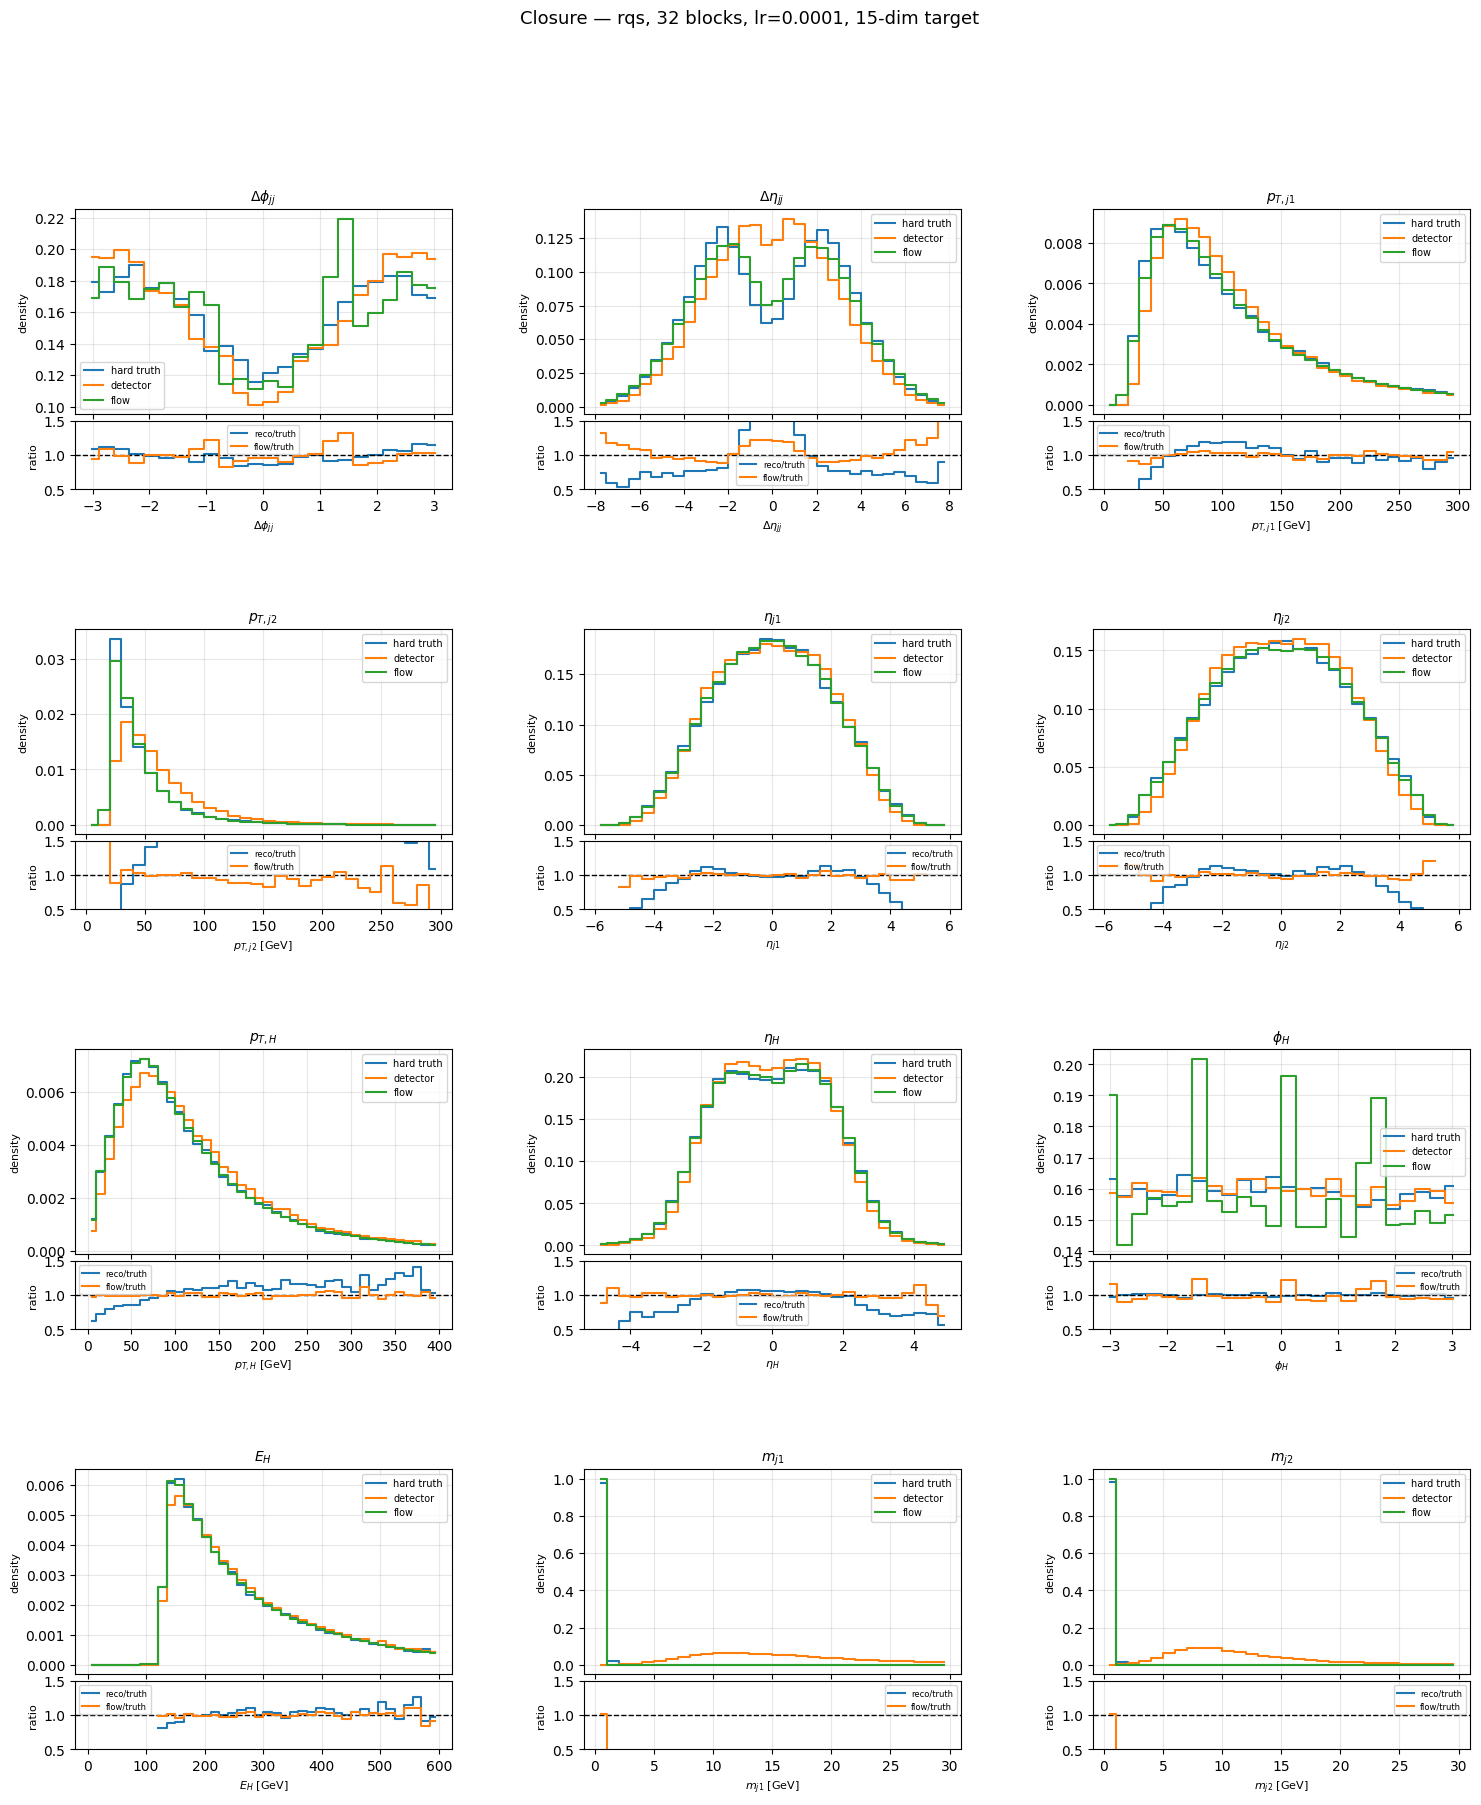

In [95]:
# ── Cell 14: Closure plots ────────────────────────────────────

def hist_density(values, bins):
    counts, edges = np.histogram(values, bins=bins, density=False)
    widths  = np.diff(edges)
    area    = np.sum(counts * widths)
    density = counts / area if area > 0 else np.zeros_like(counts, dtype=float)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return density, centers

def safe_ratio(num, den):
    out  = np.full_like(num, np.nan, dtype=float)
    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out

plot_specs = [
    ("dphi",   np.linspace(-np.pi, np.pi, 25), r"$\Delta\phi_{jj}$",  r"$\Delta\phi_{jj}$"),
    ("deta",   np.linspace(-8, 8, 33),          r"$\Delta\eta_{jj}$",  r"$\Delta\eta_{jj}$"),
    ("j1_pt",  np.linspace(0, 300, 31),         r"$p_{T,j1}$ [GeV]",  r"$p_{T,j1}$"),
    ("j2_pt",  np.linspace(0, 300, 31),         r"$p_{T,j2}$ [GeV]",  r"$p_{T,j2}$"),
    ("j1_eta", np.linspace(-6, 6, 31),          r"$\eta_{j1}$",        r"$\eta_{j1}$"),
    ("j2_eta", np.linspace(-6, 6, 31),          r"$\eta_{j2}$",        r"$\eta_{j2}$"),
    ("H_pt",   np.linspace(0, 400, 41),         r"$p_{T,H}$ [GeV]",   r"$p_{T,H}$"),
    ("H_eta",  np.linspace(-5, 5, 31),          r"$\eta_H$",           r"$\eta_H$"),
    ("H_phi",  np.linspace(-np.pi, np.pi, 25),  r"$\phi_H$",           r"$\phi_H$"),
    ("H_E",    np.linspace(0, 600, 41),         r"$E_H$ [GeV]",        r"$E_H$"),
    ("j1_m",   np.linspace(0, 30, 31),          r"$m_{j1}$ [GeV]",     r"$m_{j1}$"),
    ("j2_m",   np.linspace(0, 30, 31),          r"$m_{j2}$ [GeV]",     r"$m_{j2}$"),
]

ncols  = 3
nplots = len(plot_specs)
nrows  = int(np.ceil(nplots / ncols))

fig = plt.figure(figsize=(18, 5 * nrows))
outer = fig.add_gridspec(nrows, ncols, hspace=0.5, wspace=0.35)

for i, (key, bins, xlabel, title) in enumerate(plot_specs):
    col = i % ncols
    row = i // ncols

    inner = outer[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax    = fig.add_subplot(inner[0])
    rax   = fig.add_subplot(inner[1], sharex=ax)

    truth_h, centers = hist_density(truth_obs[key], bins)
    flow_h,  _       = hist_density(flow_obs[key],  bins)  # ← only once now

    flow_ratio = safe_ratio(flow_h, truth_h)

    ax.step(centers, truth_h, where="mid", linewidth=1.5, label="hard truth")

    if key in reco_obs:
        reco_h, _  = hist_density(reco_obs[key], bins)
        reco_ratio = safe_ratio(reco_h, truth_h)
        ax.step(centers, reco_h,  where="mid", linewidth=1.5, label="detector")
        rax.step(centers, reco_ratio, where="mid", linewidth=1.5, label="reco/truth")

    ax.step(centers, flow_h,  where="mid", linewidth=1.5, label="flow")
    ax.set_ylabel("density", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
    ax.tick_params(labelbottom=False)

    rax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    rax.step(centers, flow_ratio, where="mid", linewidth=1.5, label="flow/truth")
    rax.set_xlabel(xlabel, fontsize=8)
    rax.set_ylabel("ratio",   fontsize=8)
    rax.set_ylim(0.5, 1.5)
    rax.grid(alpha=0.3)
    rax.legend(fontsize=6)

fig.suptitle(
    f"Closure — {COUPLING_TYPE}, {N_BLOCKS} blocks, "
    f"lr={LR}, {y_dim}-dim target",
    fontsize=13,
)
plt.show()

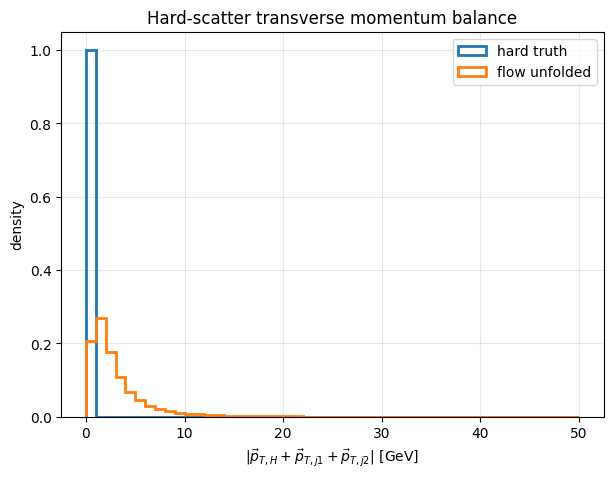

Truth pT balance — mean: 0.00, median: 0.00
Flow  pT balance — mean: 3.32,  median: 2.11
Finite fraction: 1.0000


In [96]:
# ── Cell 15: pT balance diagnostic ───────────────────────────

def px_from_features(feat):
    pt  = pt_from_features(feat)
    phi = phi_from_features(feat)
    return pt * np.cos(phi)

def py_from_features(feat):
    pt  = pt_from_features(feat)
    phi = phi_from_features(feat)
    return pt * np.sin(phi)

def pT_balance(arr):
    """
    Compute |pT_H + pT_j1 + pT_j2| for each event.
    Note: j2 phi slot = Δφ_jj, so we recover phi_j2 first.
    """
    H_feat  = block(arr, "H")
    j1_feat = block(arr, "j1")

    phi_j2  = phi_j2_from_samples(arr)
    pt_j2   = pt_from_features(block(arr, "j2"))

    px_sum = (
        px_from_features(H_feat)
        + px_from_features(j1_feat)
        + pt_j2 * np.cos(phi_j2)
    )
    py_sum = (
        py_from_features(H_feat)
        + py_from_features(j1_feat)
        + pt_j2 * np.sin(phi_j2)
    )

    return np.sqrt(px_sum**2 + py_sum**2)


truth_balance = pT_balance(truth_samples_all)
flow_balance  = pT_balance(flow_samples_all)

plt.figure(figsize=(7, 5))
plt.hist(truth_balance, bins=np.linspace(0, 50, 51), density=True,
         histtype="step", linewidth=2, label="hard truth")
plt.hist(flow_balance,  bins=np.linspace(0, 50, 51), density=True,
         histtype="step", linewidth=2, label="flow unfolded")
plt.xlabel(r"$|\vec{p}_{T,H} + \vec{p}_{T,j1} + \vec{p}_{T,j2}|$ [GeV]")
plt.ylabel("density")
plt.title("Hard-scatter transverse momentum balance")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Truth pT balance — mean: {np.mean(truth_balance):.2f}, median: {np.median(truth_balance):.2f}")
print(f"Flow  pT balance — mean: {np.mean(flow_balance):.2f},  median: {np.median(flow_balance):.2f}")

finite = np.isfinite(flow_balance)
print(f"Finite fraction: {np.mean(finite):.4f}")

at_1_bt_0:
  truth-reco correlation: 0.253
  truth-flow correlation: 0.348
at_0_bt_1:
  truth-reco correlation: 0.271
  truth-flow correlation: 0.341
at_1_bt_1:
  truth-reco correlation: 0.253
  truth-flow correlation: 0.359


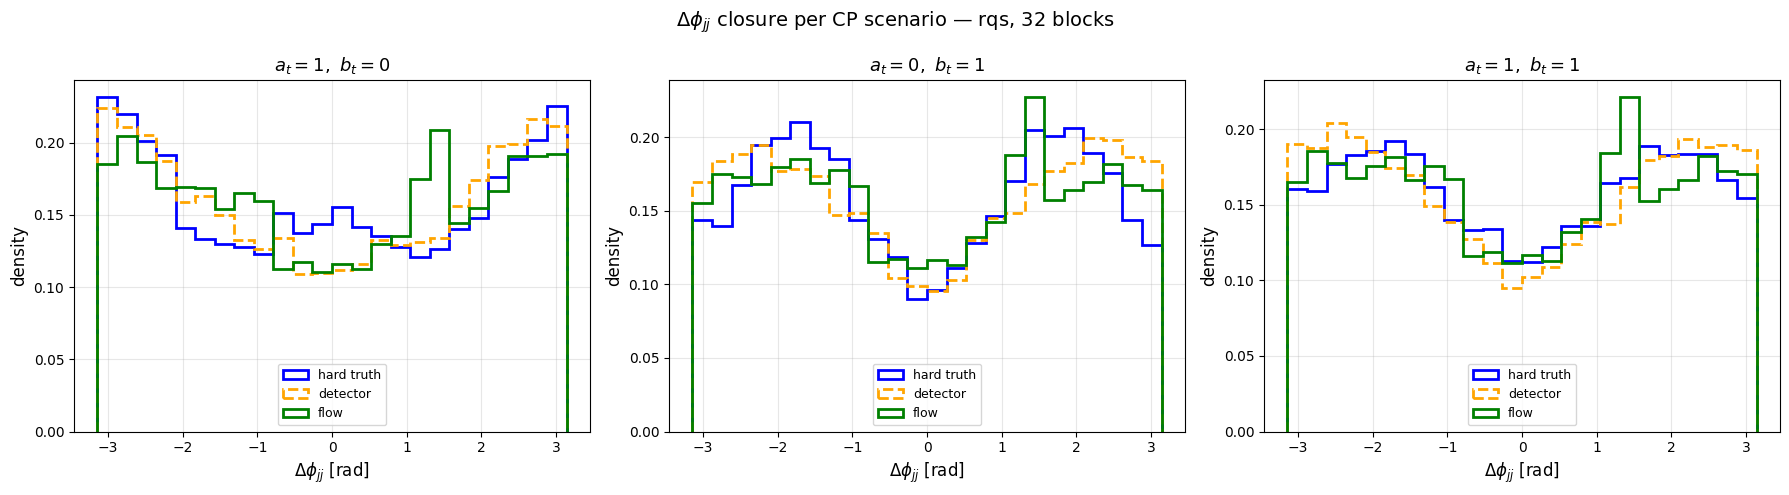

In [97]:
# ── Cell 16: Δφ_jj closure per coupling configuration ────────────────────────

bins    = np.linspace(-np.pi, np.pi, 25)
configs = ["at_1_bt_0", "at_0_bt_1", "at_1_bt_1"]
labels  = {"at_1_bt_0": r"$a_t=1,\ b_t=0$",
           "at_0_bt_1": r"$a_t=0,\ b_t=1$",
           "at_1_bt_1": r"$a_t=1,\ b_t=1$"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, config in zip(axes, configs):

    mask      = meta_val["sample"].values == config
    flow_mask = np.repeat(mask, N_SAMPLES_PER_EVENT)

    # truth
    truth_dphi = dphi_jj_from_samples(y_val[mask])

    # reco
    reco_dphi = np.array([
        delta_phi(
            phi_from_reco_features(jet_features_from_reco_X(row, 0)),
            phi_from_reco_features(jet_features_from_reco_X(row, 1)),
        )
        for row in X_val[mask]
    ])

    # flow
    flow_dphi = dphi_jj_from_samples(flow_samples_all[flow_mask])

    # plot
    ax.hist(truth_dphi, bins=bins, density=True, histtype="step",
            linewidth=2, color="blue",   label="hard truth")
    ax.hist(reco_dphi,  bins=bins, density=True, histtype="step",
            linewidth=2, color="orange", linestyle="--", label="detector")
    ax.hist(flow_dphi,  bins=bins, density=True, histtype="step",
            linewidth=2, color="green",  label="flow")

    ax.set_xlabel(r"$\Delta\phi_{jj}$ [rad]", fontsize=12)
    ax.set_ylabel("density", fontsize=12)
    ax.set_title(labels[config], fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    corr_truth_reco = np.corrcoef(truth_dphi, reco_dphi)[0, 1]
    flow_dphi_reshaped = flow_dphi.reshape(mask.sum(), N_SAMPLES_PER_EVENT)
    flow_dphi_median   = np.median(flow_dphi_reshaped, axis=1)
    corr_truth_flow    = np.corrcoef(truth_dphi, flow_dphi_median)[0, 1]
    print(f"{config}:")
    print(f"  truth-reco correlation: {corr_truth_reco:.3f}")
    print(f"  truth-flow correlation: {corr_truth_flow:.3f}")

fig.suptitle(
    r"$\Delta\phi_{jj}$ closure per CP scenario — rqs, 32 blocks",
    fontsize=14,
)
plt.tight_layout()
plt.show()

# 17. Invariant mass reconstruction

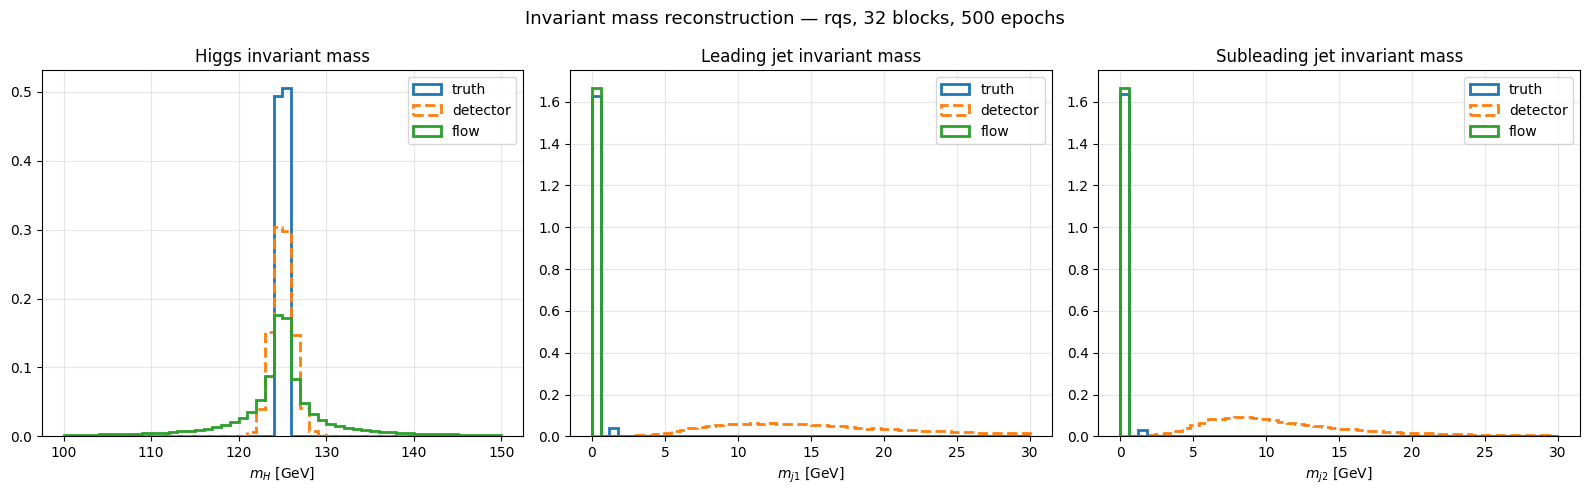

Flow  Higgs mass — mean: 123.37, median: 124.89 GeV
Truth Higgs mass — mean: 125.00, median: 125.00 GeV
Reco  Higgs mass — mean: 124.99, median: 124.99 GeV
── Higgs ──
  Truth    : mean=125.000  median=125.000  std=0.013  GeV
  Detector : mean=124.993  median=124.987  std=1.258  GeV
  Flow     : mean=123.371  median=124.895  std=25.241  GeV
  Δmean (flow-truth) : -1.629 GeV
  Flow within 5 GeV of truth mean:  67.3%
  Flow within 15 GeV of truth mean: 85.4%

── j1 ──
  Truth    : mean=0.034  median=0.000  std=0.224  GeV
  Detector : mean=19.572  median=15.941  std=13.802  GeV
  Flow     : mean=-0.000  median=-0.000  std=0.002  GeV
  Δmean (flow-truth) : -0.034 GeV
  Flow within 5 GeV of truth mean:  100.0%
  Flow within 15 GeV of truth mean: 100.0%

── j2 ──
  Truth    : mean=0.026  median=0.000  std=0.194  GeV
  Detector : mean=12.251  median=10.341  std=7.648  GeV
  Flow     : mean=-0.000  median=-0.000  std=0.001  GeV
  Δmean (flow-truth) : -0.026 GeV
  Flow within 5 GeV of truth mea

In [98]:
four_vecs = reconstruct_four_vectors(flow_samples_all)
four_vecs_truth = reconstruct_four_vectors(truth_samples_all)

# Instead of deriving from four-vectors, read directly from samples
m_H_flow  = mass_from_four_vector(four_vecs["H"])  # Higgs still needs four-vector route
m_j1_flow = mass_from_features(block(flow_samples_all, "j1"))   # direct
m_j2_flow = mass_from_features(block(flow_samples_all, "j2"))   # direct

m_H_truth  = mass_from_four_vector(four_vecs_truth["H"])
m_j1_truth = mass_from_features(block(truth_samples_all, "j1"))  # direct
m_j2_truth = mass_from_features(block(truth_samples_all, "j2"))  # direct


# ── Reco masses from X_val (unscaled) ───────────────────────────────────────
X_val_unscaled = (X_val_s * x_scale) + x_mean
# Higgs mass: index 4 in reco vector
m_H_reco = X_val_unscaled[:, 4]

# j1 mass: first jet slot starts at index 7, each jet has 6 features → mass is offset 4
# jet layout: [log1p_pt, eta, sinphi, cosphi, mass, log1p_E] × 12 jets, starting at index 7
m_j1_reco = X_val_unscaled[:, 7 + 4]       # index 11
m_j2_reco = X_val_unscaled[:, 7 + 6 + 4]   # index 17

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(m_H_truth, bins=np.linspace(100, 150, 51), density=True,
             histtype="step", linewidth=2, label="truth")
axes[0].hist(m_H_reco,  bins=np.linspace(100, 150, 51), density=True,
             histtype="step", linewidth=2, label="detector", linestyle="dashed")
axes[0].hist(m_H_flow,  bins=np.linspace(100, 150, 51), density=True,
             histtype="step", linewidth=2, label="flow")
axes[0].set_xlabel(r"$m_H$ [GeV]")
axes[0].set_title("Higgs invariant mass")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(m_j1_truth, bins=np.linspace(0, 30, 51), density=True,
             histtype="step", linewidth=2, label="truth")
axes[1].hist(m_j1_reco,  bins=np.linspace(0, 30, 51), density=True,
             histtype="step", linewidth=2, label="detector", linestyle="dashed")
axes[1].hist(m_j1_flow,  bins=np.linspace(0, 30, 51), density=True,
             histtype="step", linewidth=2, label="flow")
axes[1].set_xlabel(r"$m_{j1}$ [GeV]")
axes[1].set_title("Leading jet invariant mass")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].hist(m_j2_truth, bins=np.linspace(0, 30, 51), density=True,
             histtype="step", linewidth=2, label="truth")
axes[2].hist(m_j2_reco,  bins=np.linspace(0, 30, 51), density=True,
             histtype="step", linewidth=2, label="detector", linestyle="dashed")
axes[2].hist(m_j2_flow,  bins=np.linspace(0, 30, 51), density=True,
             histtype="step", linewidth=2, label="flow")
axes[2].set_xlabel(r"$m_{j2}$ [GeV]")
axes[2].set_title("Subleading jet invariant mass")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle(
    f"Invariant mass reconstruction — {COUPLING_TYPE}, {N_BLOCKS} blocks, "
    f"{len(train_losses)} epochs",
    fontsize=13,
)
plt.tight_layout()
plt.show()

print(f"Flow  Higgs mass — mean: {np.mean(m_H_flow):.2f}, median: {np.median(m_H_flow):.2f} GeV")
print(f"Truth Higgs mass — mean: {np.mean(m_H_truth):.2f}, median: {np.median(m_H_truth):.2f} GeV")
print(f"Reco  Higgs mass — mean: {np.mean(m_H_reco):.2f}, median: {np.median(m_H_reco):.2f} GeV")

for name, flow_m, truth_m, reco_m in [
    ("Higgs", m_H_flow, m_H_truth, m_H_reco),
    ("j1",    m_j1_flow, m_j1_truth, m_j1_reco),
    ("j2",    m_j2_flow, m_j2_truth, m_j2_reco),
]:
    print(f"── {name} ──")
    print(f"  Truth    : mean={np.nanmean(truth_m):.3f}  median={np.nanmedian(truth_m):.3f}  std={np.nanstd(truth_m):.3f}  GeV")
    print(f"  Detector : mean={np.nanmean(reco_m):.3f}  median={np.nanmedian(reco_m):.3f}  std={np.nanstd(reco_m):.3f}  GeV")
    print(f"  Flow     : mean={np.nanmean(flow_m):.3f}  median={np.nanmedian(flow_m):.3f}  std={np.nanstd(flow_m):.3f}  GeV")
    print(f"  Δmean (flow-truth) : {np.nanmean(flow_m) - np.nanmean(truth_m):+.3f} GeV")
    print(f"  Flow within 5 GeV of truth mean:  {np.nanmean(np.abs(flow_m - np.nanmean(truth_m)) < 5)*100:.1f}%")
    print(f"  Flow within 15 GeV of truth mean: {np.nanmean(np.abs(flow_m - np.nanmean(truth_m)) < 15)*100:.1f}%")
    print()

In [77]:
for name, flow_m in [("j1", m_j1_flow), ("j2", m_j2_flow)]:
    print(f"{name}:")
    print(f"  > 10 GeV:  {np.nanmean(flow_m > 10)*100:.1f}%")
    print(f"  > 50 GeV:  {np.nanmean(flow_m > 50)*100:.1f}%")
    print(f"  > 100 GeV: {np.nanmean(flow_m > 100)*100:.1f}%")
    print(f"  median: {np.nanmedian(flow_m):.2f} GeV")

j1:
  > 10 GeV:  44.9%
  > 50 GeV:  20.0%
  > 100 GeV: 11.4%
  median: 4.75 GeV
j2:
  > 10 GeV:  34.4%
  > 50 GeV:  13.8%
  > 100 GeV: 7.7%
  median: 2.41 GeV


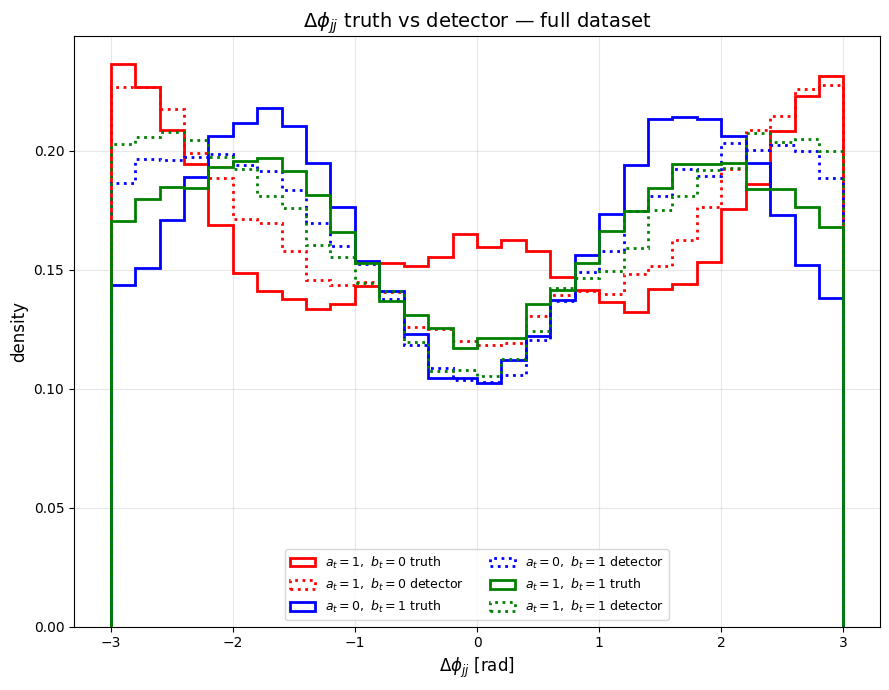

In [58]:

bins    = np.linspace(-3,3,31)
configs = ["at_1_bt_0", "at_0_bt_1", "at_1_bt_1"]
labels  = {"at_1_bt_0": r"$a_t=1,\ b_t=0$",
           "at_0_bt_1": r"$a_t=0,\ b_t=1$",
           "at_1_bt_1": r"$a_t=1,\ b_t=1$"}
colors  = {"at_1_bt_0": "red", "at_0_bt_1": "blue", "at_1_bt_1": "green"}

plt.figure(figsize=(9, 7))

for config in configs:
    mask = meta["sample"].values == config

    truth_dphi = dphi_jj_from_samples(y[mask])

    reco_dphi = np.array([
        delta_phi(
            phi_from_reco_features(jet_features_from_reco_X(row, 0)),
            phi_from_reco_features(jet_features_from_reco_X(row, 1)),
        )
        for row in X[mask]
    ])

    plt.hist(truth_dphi, bins=bins, density=True, histtype="step",
             linewidth=2, color=colors[config],
             label=f"{labels[config]} truth")
    plt.hist(reco_dphi,  bins=bins, density=True, histtype="step",
             linewidth=2, color=colors[config], linestyle=":",
             label=f"{labels[config]} detector")

plt.xlabel(r"$\Delta\phi_{jj}$ [rad]", fontsize=12)
plt.ylabel("density", fontsize=12)
plt.title(r"$\Delta\phi_{jj}$ truth vs detector — full dataset", fontsize=14)
plt.legend(fontsize=9, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

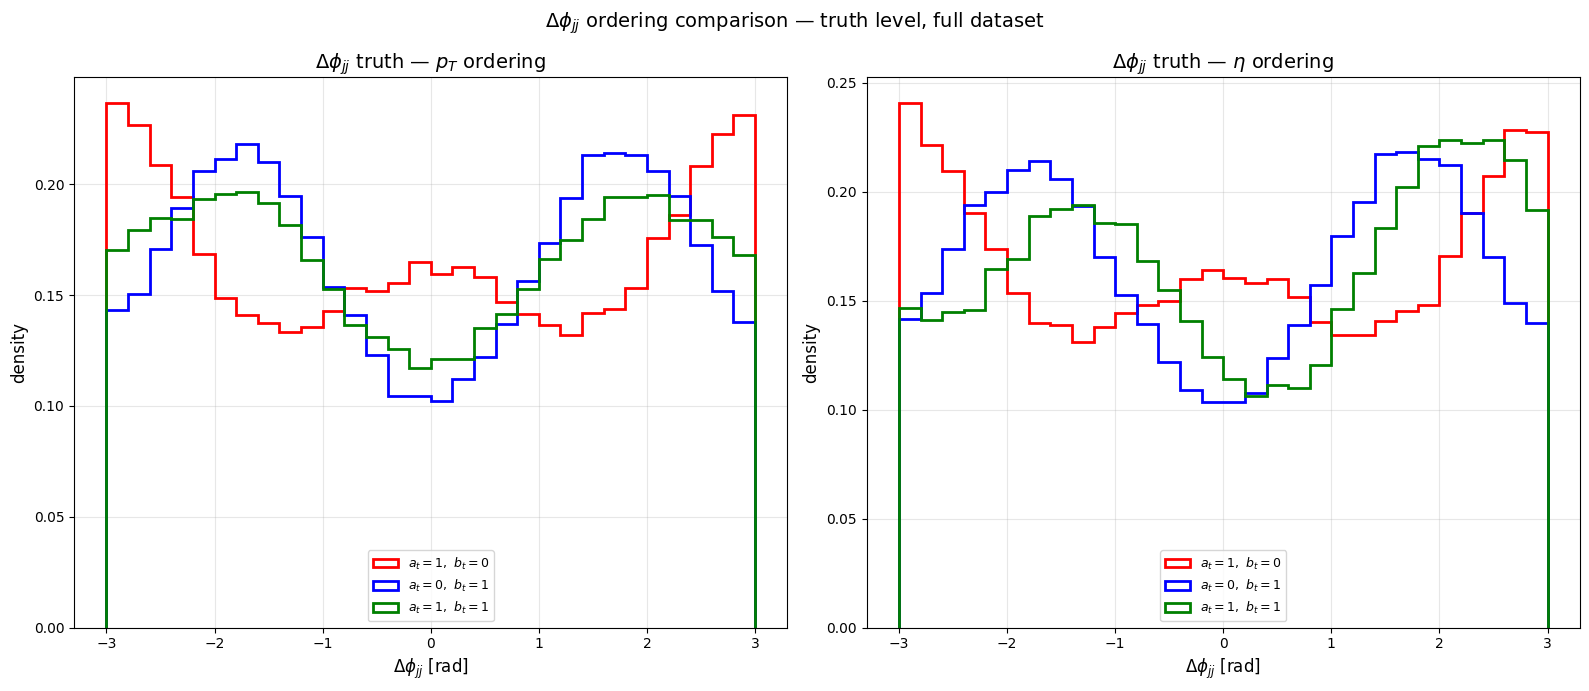

In [17]:
# ── Δφ_jj ordering comparison: pT vs η ───────────────────────────────────────

bins    = np.linspace(-3, 3, 31)
configs = ["at_1_bt_0", "at_0_bt_1", "at_1_bt_1"]
labels  = {"at_1_bt_0": r"$a_t=1,\ b_t=0$",
           "at_0_bt_1": r"$a_t=0,\ b_t=1$",
           "at_1_bt_1": r"$a_t=1,\ b_t=1$"}
colors  = {"at_1_bt_0": "red", "at_0_bt_1": "blue", "at_1_bt_1": "green"}

# extract parton kinematics from full truth array
j1_eta = eta_from_features(block(y_full, "j1"))
j1_phi = phi_from_features(block(y_full, "j1"))
j2_phi = phi_j2_from_samples(y_full)    # recover raw phi_j2
j2_eta = eta_from_features(block(y_full, "j2"))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: pT ordering (current) ──────────────────────────────────────────────
ax = axes[0]
for config in configs:
    mask = meta_full["sample"].values == config
    dphi = dphi_jj_from_samples(y_full[mask])
    ax.hist(dphi, bins=bins, density=True, histtype="step",
            linewidth=2, color=colors[config],
            label=f"{labels[config]}")

ax.set_xlabel(r"$\Delta\phi_{jj}$ [rad]", fontsize=12)
ax.set_ylabel("density", fontsize=12)
ax.set_title(r"$\Delta\phi_{jj}$ truth — $p_T$ ordering", fontsize=14)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Right: η ordering ─────────────────────────────────────────────────────────
ax = axes[1]
for config in configs:
    mask = meta_full["sample"].values == config

    eta1 = j1_eta[mask];  phi1 = j1_phi[mask]
    eta2 = j2_eta[mask];  phi2 = j2_phi[mask]

    # swap so that eta1 >= eta2 (most forward first)
    swap     = eta1 < eta2
    phi1_ord = np.where(swap, phi2, phi1)
    phi2_ord = np.where(swap, phi1, phi2)

    dphi = delta_phi(phi1_ord, phi2_ord)

    ax.hist(dphi, bins=bins, density=True, histtype="step",
            linewidth=2, color=colors[config],
            label=f"{labels[config]}")

ax.set_xlabel(r"$\Delta\phi_{jj}$ [rad]", fontsize=12)
ax.set_ylabel("density", fontsize=12)
ax.set_title(r"$\Delta\phi_{jj}$ truth — $\eta$ ordering", fontsize=14)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle(r"$\Delta\phi_{jj}$ ordering comparison — truth level, full dataset", fontsize=14)
plt.tight_layout()
plt.show()

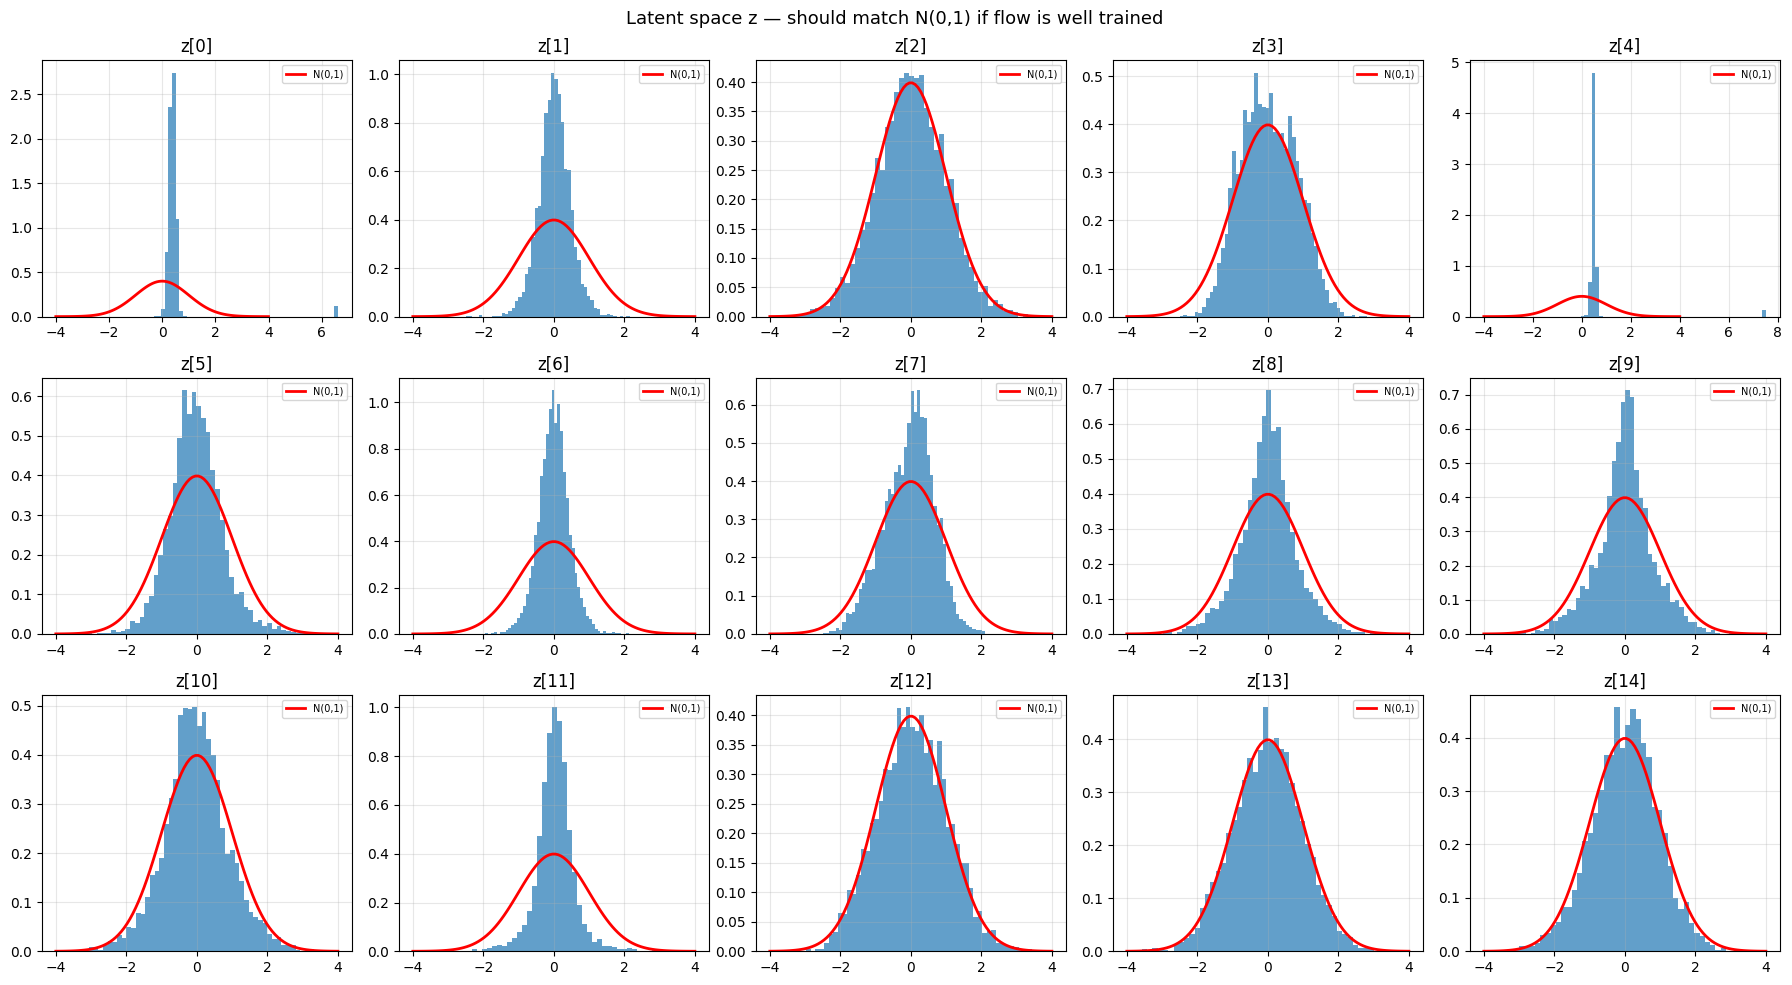

z statistics (should be mean≈0, std≈1):
  mean: [ 0.485  0.015  0.018  0.02   0.62  -0.025 -0.002 -0.053 -0.007  0.012
 -0.015  0.034  0.051 -0.01   0.007]
  std:  [0.796 0.452 0.985 0.79  0.967 0.738 0.438 0.709 0.775 0.799 0.899 0.562
 0.985 0.981 0.942]


In [103]:
model.eval()
with torch.no_grad():
    z_val, log_det_val = model(
        torch.tensor(y_val_s[:5000], dtype=torch.float32, device=device),
        torch.tensor(X_val_s[:5000], dtype=torch.float32, device=device),
    )
z_val = z_val.cpu().numpy()

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i in range(15):
    axes[i].hist(z_val[:, i], bins=50, density=True, alpha=0.7)
    # overlay standard normal
    x_range = np.linspace(-4, 4, 100)
    axes[i].plot(x_range, 
                 np.exp(-0.5 * x_range**2) / np.sqrt(2 * np.pi), 
                 'r-', linewidth=2, label="N(0,1)")
    axes[i].set_title(f"z[{i}]")
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)

plt.suptitle("Latent space z — should match N(0,1) if flow is well trained", fontsize=13)
plt.tight_layout()
plt.show()

# quantitative check
print("z statistics (should be mean≈0, std≈1):")
print(f"  mean: {z_val.mean(axis=0).round(3)}")
print(f"  std:  {z_val.std(axis=0).round(3)}")

In [105]:
import uproot
import awkward as ak

input_files = {
    "at_1_bt_0": "Delphes_Data/at_1_bt_0/tag_1_delphes_events.root",
    "at_0_bt_1": "Delphes_Data/at_0_bt_1/tag_1_delphes_events.root",
    "at_1_bt_1": "Delphes_Data/at_1_bt_1/tag_1_delphes_events.root",
}
TREE_NAME = "Delphes"

branches = ["Particle.PID", "Particle.Status", "Particle.PT"]

for sample_name, path in input_files.items():
    print(f"\n── {sample_name} ──")
    with uproot.open(path) as f:
        arr = f[TREE_NAME].arrays(branches, library="ak")

    pid    = arr["Particle.PID"]
    status = arr["Particle.Status"]

    is_higgs       = (pid == 25) & (status == 22)
    is_hard_parton = (status == 23) & ((pid == 21) | (abs(pid) <= 5))

    n_higgs   = ak.num(arr["Particle.PT"][is_higgs])
    n_partons = ak.num(arr["Particle.PT"][is_hard_parton])

    print(f"  Total events          : {len(n_higgs):,}")
    print(f"  Events with != 1 Higgs  : {ak.sum(n_higgs != 1):,}")
    print(f"  Events with != 2 partons: {ak.sum(n_partons != 2):,}")


── at_1_bt_0 ──
  Total events          : 200,000
  Events with != 1 Higgs  : 0
  Events with != 2 partons: 0

── at_0_bt_1 ──
  Total events          : 200,000
  Events with != 1 Higgs  : 0
  Events with != 2 partons: 0

── at_1_bt_1 ──
  Total events          : 200,000
  Events with != 1 Higgs  : 0
  Events with != 2 partons: 0


In [106]:
import uproot
import awkward as ak
import numpy as np

input_files = {
    "at_1_bt_0": "Delphes_Data/at_1_bt_0/tag_1_delphes_events.root",
    "at_0_bt_1": "Delphes_Data/at_0_bt_1/tag_1_delphes_events.root",
    "at_1_bt_1": "Delphes_Data/at_1_bt_1/tag_1_delphes_events.root",
}
TREE_NAME   = "Delphes"
MASS_WINDOW = 15.0

branches = [
    "Particle.PID", "Particle.Status", "Particle.PT",
    "Jet.PT", "Photon.PT", "Photon.Eta", "Photon.Phi", "Photon.E",
]

def photons_to_higgs_mass(pt1, eta1, phi1, e1, pt2, eta2, phi2, e2):
    px1 = pt1*np.cos(phi1); py1 = pt1*np.sin(phi1); pz1 = pt1*np.sinh(eta1)
    px2 = pt2*np.cos(phi2); py2 = pt2*np.sin(phi2); pz2 = pt2*np.sinh(eta2)
    e   = e1+e2; px = px1+px2; py = py1+py2; pz = pz1+pz2
    return np.sqrt(np.maximum(e**2 - px**2 - py**2 - pz**2, 0.0))

print(f"{'Cut':<35} {'at_1_bt_0':>12} {'at_0_bt_1':>12} {'at_1_bt_1':>12} {'total':>12}")
print("─" * 75)

totals = {}

for sample_name, path in input_files.items():
    with uproot.open(path) as f:
        arr = f[TREE_NAME].arrays(branches, library="ak")

    pid    = arr["Particle.PID"]
    status = arr["Particle.Status"]

    is_higgs       = (pid == 25) & (status == 22)
    is_hard_parton = (status == 23) & ((pid == 21) | (abs(pid) <= 5))

    n_higgs   = ak.num(arr["Particle.PT"][is_higgs])
    n_partons = ak.num(arr["Particle.PT"][is_hard_parton])
    n_jets    = ak.num(arr["Jet.PT"])
    n_photons = ak.num(arr["Photon.PT"])

    # cumulative mask
    mask_gen     = (n_higgs == 1) & (n_partons == 2)
    mask_photons = mask_gen & (n_photons >= 2)
    mask_jets    = mask_photons & (n_jets >= 2)

    # mass window — needs diphoton reconstruction
    pho_pt  = arr["Photon.PT"][mask_jets]
    pho_eta = arr["Photon.Eta"][mask_jets]
    pho_phi = arr["Photon.Phi"][mask_jets]
    pho_e   = arr["Photon.E"][mask_jets]

    hrec_m = photons_to_higgs_mass(
        ak.to_numpy(pho_pt[:, 0]),  ak.to_numpy(pho_eta[:, 0]),
        ak.to_numpy(pho_phi[:, 0]), ak.to_numpy(pho_e[:, 0]),
        ak.to_numpy(pho_pt[:, 1]),  ak.to_numpy(pho_eta[:, 1]),
        ak.to_numpy(pho_phi[:, 1]), ak.to_numpy(pho_e[:, 1]),
    )
    mass_mask = np.abs(hrec_m - 125.0) < MASS_WINDOW

    totals[sample_name] = {
        "all events":              int(len(mask_gen)),
        "≥1 Higgs + 2 partons":   int(ak.sum(mask_gen)),
        "≥2 photons":             int(ak.sum(mask_photons)),
        "≥2 reco jets":           int(ak.sum(mask_jets)),
        f"|m_γγ-125|<{MASS_WINDOW} GeV": int(np.sum(mask_mask := mass_mask)),
    }

# ── Print cutflow table ───────────────────────────────────────
cut_names = list(list(totals.values())[0].keys())
samples   = list(totals.keys())

for cut in cut_names:
    counts = [totals[s][cut] for s in samples]
    total  = sum(counts)
    print(f"{cut:<35} {counts[0]:>12,} {counts[1]:>12,} {counts[2]:>12,} {total:>12,}")

print("─" * 75)

# ── Print efficiency at each step ─────────────────────────────
print(f"\n{'Cut':<35} {'efficiency':>12}")
print("─" * 50)
prev_total = sum(totals[s]["all events"] for s in samples)
for cut in cut_names:
    total = sum(totals[s][cut] for s in samples)
    eff   = total / prev_total * 100
    print(f"{cut:<35} {eff:>11.1f}%")
    prev_total = total

Cut                                    at_1_bt_0    at_0_bt_1    at_1_bt_1        total
───────────────────────────────────────────────────────────────────────────
all events                               200,000      200,000      200,000      600,000
≥1 Higgs + 2 partons                     200,000      200,000      200,000      600,000
≥2 photons                                96,265       96,429       96,642      289,336
≥2 reco jets                              88,491       88,388       88,695      265,574
|m_γγ-125|<15.0 GeV                       88,020       87,895       88,178      264,093
───────────────────────────────────────────────────────────────────────────

Cut                                   efficiency
──────────────────────────────────────────────────
all events                                100.0%
≥1 Higgs + 2 partons                      100.0%
≥2 photons                                 48.2%
≥2 reco jets                               91.8%
|m_γγ-125|<15.0 GeV    

In [109]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import os

input_files = {
    "at_1_bt_0": "Delphes_Data/at_1_bt_0/tag_1_delphes_events.root",
    "at_0_bt_1": "Delphes_Data/at_0_bt_1/tag_1_delphes_events.root",
    "at_1_bt_1": "Delphes_Data/at_1_bt_1/tag_1_delphes_events.root",
}
TREE_NAME = "Delphes"

branches = [
    "Particle.PID", "Particle.Status",
    "Particle.PT", "Particle.Eta", "Particle.Phi",
    "Particle.E",
]

os.makedirs("forMarcel", exist_ok=True)

for sample_name, path in input_files.items():
    print(f"Processing {sample_name}...")
    with uproot.open(path) as f:
        arr = f[TREE_NAME].arrays(branches, library="ak")

    pid    = arr["Particle.PID"]
    status = arr["Particle.Status"]

    is_higgs       = (pid == 25) & (status == 22)
    is_hard_parton = (status == 23) & ((pid == 21) | (abs(pid) <= 5))

    h_pt  = ak.to_numpy(arr["Particle.PT"][is_higgs][:, 0])
    h_eta = ak.to_numpy(arr["Particle.Eta"][is_higgs][:, 0])
    h_phi = ak.to_numpy(arr["Particle.Phi"][is_higgs][:, 0])
    h_E   = ak.to_numpy(arr["Particle.E"][is_higgs][:, 0])

    p_pt  = ak.to_numpy(arr["Particle.PT"][is_hard_parton])
    p_eta = ak.to_numpy(arr["Particle.Eta"][is_hard_parton])
    p_phi = ak.to_numpy(arr["Particle.Phi"][is_hard_parton])
    p_E   = ak.to_numpy(arr["Particle.E"][is_hard_parton])

    # ── pT ordering: leading pT first ────────────────────────────
    swap = p_pt[:, 0] < p_pt[:, 1]
    for a in [p_pt, p_eta, p_phi, p_E]:
        tmp = a[swap, 0].copy()
        a[swap, 0] = a[swap, 1]
        a[swap, 1] = tmp

    def to_cartesian(pt, eta, phi, E):
        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)
        return E, px, py, pz

    H_E,  H_px,  H_py,  H_pz  = to_cartesian(h_pt,      h_eta,      h_phi,      h_E)
    j1_E, j1_px, j1_py, j1_pz = to_cartesian(p_pt[:,0], p_eta[:,0], p_phi[:,0], p_E[:,0])
    j2_E, j2_px, j2_py, j2_pz = to_cartesian(p_pt[:,1], p_eta[:,1], p_phi[:,1], p_E[:,1])

    df = pd.DataFrame({
        "H_E":   H_E,   "H_px":  H_px,  "H_py":  H_py,  "H_pz":  H_pz,
        "j1_E":  j1_E,  "j1_px": j1_px, "j1_py": j1_py, "j1_pz": j1_pz,
        "j2_E":  j2_E,  "j2_px": j2_px, "j2_py": j2_py, "j2_pz": j2_pz,
    }).astype(np.float32)

    out_path = f"forMarcel/{sample_name}.h5"
    df.to_hdf(out_path, key="events", mode="w")

    print(f"  {len(df):,} events → {out_path}")
    print(f"  Columns: {list(df.columns)}")

print("\nDone. Files in forMarcel/:")
for f in os.listdir("forMarcel"):
    size = os.path.getsize(f"forMarcel/{f}") / 1e6
    print(f"  {f}: {size:.1f} MB")

Processing at_1_bt_0...
  200,000 events → forMarcel/at_1_bt_0.h5
  Columns: ['H_E', 'H_px', 'H_py', 'H_pz', 'j1_E', 'j1_px', 'j1_py', 'j1_pz', 'j2_E', 'j2_px', 'j2_py', 'j2_pz']
Processing at_0_bt_1...
  200,000 events → forMarcel/at_0_bt_1.h5
  Columns: ['H_E', 'H_px', 'H_py', 'H_pz', 'j1_E', 'j1_px', 'j1_py', 'j1_pz', 'j2_E', 'j2_px', 'j2_py', 'j2_pz']
Processing at_1_bt_1...
  200,000 events → forMarcel/at_1_bt_1.h5
  Columns: ['H_E', 'H_px', 'H_py', 'H_pz', 'j1_E', 'j1_px', 'j1_py', 'j1_pz', 'j2_E', 'j2_px', 'j2_py', 'j2_pz']

Done. Files in forMarcel/:
  at_0_bt_1.h5: 11.2 MB
  at_1_bt_0.h5: 11.2 MB
  at_1_bt_1.h5: 11.2 MB


In [110]:
import pandas as pd
import numpy as np
import os

samples = ["at_1_bt_0", "at_0_bt_1", "at_1_bt_1"]

for sample_name in samples:
    path = f"forMarcel/{sample_name}.h5"
    df   = pd.read_hdf(path, key="events")

    print(f"\n── {sample_name} ──")

    # 1. shape
    assert df.shape == (200000, 12), f"Wrong shape: {df.shape}"
    print(f"  Shape: {df.shape} ✓")

    # 2. no NaNs
    assert df.isnull().sum().sum() == 0, "NaNs found"
    print(f"  No NaNs ✓")

    # 3. no infinite values
    assert np.isfinite(df.values).all(), "Infinite values found"
    print(f"  No infinite values ✓")

    # 4. Higgs mass should be ~125 GeV
    m2_H = df["H_E"]**2 - df["H_px"]**2 - df["H_py"]**2 - df["H_pz"]**2
    m_H  = np.sqrt(np.maximum(m2_H, 0))
    assert np.abs(m_H.mean() - 125.0) < 1.0, f"Higgs mass wrong: {m_H.mean():.2f} GeV"
    print(f"  Higgs mass mean: {m_H.mean():.2f} ± {m_H.std():.2f} GeV ✓")

    # 5. parton masses should be near zero
    m2_j1 = df["j1_E"]**2 - df["j1_px"]**2 - df["j1_py"]**2 - df["j1_pz"]**2
    m2_j2 = df["j2_E"]**2 - df["j2_px"]**2 - df["j2_py"]**2 - df["j2_pz"]**2
    m_j1  = np.sqrt(np.maximum(m2_j1, 0))
    m_j2  = np.sqrt(np.maximum(m2_j2, 0))
    print(f"  j1 mass mean: {m_j1.mean():.3f} GeV (should be ~0) ✓")
    print(f"  j2 mass mean: {m_j2.mean():.3f} GeV (should be ~0) ✓")

    # 6. j1 should always have higher pT than j2
    pt_j1 = np.sqrt(df["j1_px"]**2 + df["j1_py"]**2)
    pt_j2 = np.sqrt(df["j2_px"]**2 + df["j2_py"]**2)
    assert (pt_j1 >= pt_j2).all(), "pT ordering violated"
    print(f"  pT ordering j1 > j2 ✓")

    # 7. energies should all be positive
    assert (df["H_E"] > 0).all(),  "Negative H energy"
    assert (df["j1_E"] > 0).all(), "Negative j1 energy"
    assert (df["j2_E"] > 0).all(), "Negative j2 energy"
    print(f"  All energies positive ✓")

    # 8. quick summary stats
    print(f"  H_E  mean: {df['H_E'].mean():.2f} GeV")
    print(f"  j1_E mean: {df['j1_E'].mean():.2f} GeV")
    print(f"  j2_E mean: {df['j2_E'].mean():.2f} GeV")

print("\nAll files passed sanity checks.")


── at_1_bt_0 ──
  Shape: (200000, 12) ✓
  No NaNs ✓
  No infinite values ✓
  Higgs mass mean: 125.00 ± 0.01 GeV ✓
  j1 mass mean: 0.100 GeV (should be ~0) ✓
  j2 mass mean: 0.073 GeV (should be ~0) ✓
  pT ordering j1 > j2 ✓
  All energies positive ✓
  H_E  mean: 397.40 GeV
  j1_E mean: 422.93 GeV
  j2_E mean: 274.40 GeV

── at_0_bt_1 ──
  Shape: (200000, 12) ✓
  No NaNs ✓
  No infinite values ✓
  Higgs mass mean: 125.00 ± 0.01 GeV ✓
  j1 mass mean: 0.100 GeV (should be ~0) ✓
  j2 mass mean: 0.072 GeV (should be ~0) ✓
  pT ordering j1 > j2 ✓
  All energies positive ✓
  H_E  mean: 404.14 GeV
  j1_E mean: 423.22 GeV
  j2_E mean: 269.83 GeV

── at_1_bt_1 ──
  Shape: (200000, 12) ✓
  No NaNs ✓
  No infinite values ✓
  Higgs mass mean: 125.00 ± 0.01 GeV ✓
  j1 mass mean: 0.101 GeV (should be ~0) ✓
  j2 mass mean: 0.072 GeV (should be ~0) ✓
  pT ordering j1 > j2 ✓
  All energies positive ✓
  H_E  mean: 401.22 GeV
  j1_E mean: 424.01 GeV
  j2_E mean: 270.59 GeV

All files passed sanity checks

In [114]:
import pandas as pd

df = pd.read_hdf("forMarcel/at_1_bt_1_hard_four_vectors.h5", key="events")

df.head()

,H_E,H_px,H_py,H_pz,j1_E,j1_px,j1_py,j1_pz,j2_E,j2_px,j2_py,j2_pz
0,145.742676,-58.552166,20.877068,41.848923,53.997494,26.684696,-18.245859,43.252113,228.525757,31.867470,-2.631212,-226.277634
1,468.821991,-28.100504,28.835707,450.053223,356.741547,40.326260,-12.779628,354.224518,29.177095,-12.225763,-16.056080,-21.072161
2,1587.330811,293.549408,360.032745,1512.679565,592.885437,-283.433716,-210.073395,476.495117,172.471207,-10.115665,-149.959366,84.594231
3,164.782608,31.694332,-101.406273,15.718170,175.059250,-14.909158,120.473312,126.124496,83.573586,-16.785179,-19.067047,-79.619408
4,357.128571,133.881042,154.333939,-264.901245,248.551285,-144.690720,-201.217056,18.815901,144.502396,10.809661,46.883106,-136.257355


In [116]:
df = pd.read_hdf("forMarcel/at_1_bt_0_hard_four_vectors.h5")

df.head()

,H_E,H_px,H_py,H_pz,j1_E,j1_px,j1_py,j1_pz,j2_E,j2_px,j2_py,j2_pz
0,225.805054,31.707285,-80.603424,166.911392,72.667381,-10.297438,67.044060,-26.069239,103.213455,-21.409838,13.559364,100.053879
1,198.859619,67.160278,-8.332683,139.067520,88.323486,-86.527580,17.328680,3.705657,126.452644,19.367311,-8.995996,124.636467
2,552.758789,-91.620621,144.126724,-510.636688,124.312080,27.766966,-120.632935,-11.409697,513.348267,63.853649,-23.493782,508.819427
3,147.143051,61.977547,39.825397,-24.474735,56.524883,-56.464470,-2.547257,-0.581034,165.233551,-5.513076,-37.278137,-160.879059
4,227.414642,73.721855,-52.546772,167.036194,439.085602,-68.115654,9.503077,433.665924,43.520016,-5.606195,43.043697,3.130929
